<a href="https://colab.research.google.com/github/SHAIKRUBINA1414/Diabetes_Prediction/blob/main/Pima_Indians_Diabetes_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Noa Pereira Prada Schnor


In [ ]:
# ============================================================
# STEP 1: VERIFY THE RAW FILES
# ============================================================

import os

print("Files available in /content:\n")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith((".zip", ".csv", ".xlsx")):
            print(os.path.join(root, file))

Files available in /content:

/content/sample_data/mnist_train_small.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/california_housing_test.csv


In [ ]:
# ============================================================
# STEP 1A: UPLOAD DATASETS TO COLAB
# ============================================================

from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving diabetes+130-us+hospitals+for+years+1999-2008.zip to diabetes+130-us+hospitals+for+years+1999-2008.zip

Uploaded files:
diabetes+130-us+hospitals+for+years+1999-2008.zip


In [ ]:
# ============================================================
# STEP 1B: VERIFY UPLOADED DATASETS
# ============================================================

import os

print("Dataset files found in /content:\n")

found = []

for root, dirs, files_list in os.walk("/content"):
    for file in files_list:
        if file.lower().endswith((".zip", ".csv", ".xlsx")):
            path = os.path.join(root, file)

            # Ignore Colab sample_data
            if "/sample_data/" not in path:
                found.append(path)

for path in found:
    print(path)

if not found:
    print("ERROR: No uploaded dataset files found.")

Dataset files found in /content:

/content/diabetes.csv
/content/Pima-Indians-Diabetes-Dataset-master (2).zip
/content/diabetes_data_upload.csv
/content/diabetes+130-us+hospitals+for+years+1999-2008.zip
/content/pima_clean/Pima-Indians-Diabetes-Dataset-master/Pima-Indians-Diabetes-Dataset-master/diabetes.csv


In [ ]:
# ============================================================
# STEP 2: LOAD RAW DATASETS
# ============================================================

import os
import zipfile
import pandas as pd

# ------------------------------------------------------------
# Find uploaded ZIP and CSV automatically
# ------------------------------------------------------------

zip_candidates = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith(".zip"):
            zip_candidates.append(os.path.join(root, file))

csv_candidates = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_candidates.append(os.path.join(root, file))

print("ZIP files:")
for f in zip_candidates:
    print(" ", f)

print("\nCSV files:")
for f in csv_candidates:
    print(" ", f)

if len(zip_candidates) == 0:
    raise FileNotFoundError(
        "Pima ZIP file was not found in /content."
    )

# Choose uploaded Pima ZIP
pima_zip = [
    f for f in zip_candidates
    if "pima" in os.path.basename(f).lower()
]

if len(pima_zip) == 0:
    raise FileNotFoundError(
        "Could not identify the Pima ZIP file."
    )

pima_zip = pima_zip[0]

# Choose UCI CSV
uci_csv = [
    f for f in csv_candidates
    if "diabetes_data_upload" in os.path.basename(f).lower()
]

if len(uci_csv) == 0:
    raise FileNotFoundError(
        "Could not identify diabetes_data_upload.csv."
    )

uci_csv = uci_csv[0]

# ------------------------------------------------------------
# Extract Pima
# ------------------------------------------------------------

extract_dir = "/content/pima_clean"

os.makedirs(
    extract_dir,
    exist_ok=True
)

with zipfile.ZipFile(
    pima_zip,
    "r"
) as z:

    z.extractall(extract_dir)

# Locate diabetes.csv
pima_csv = None

for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.lower() == "diabetes.csv":
            pima_csv = os.path.join(
                root,
                file
            )
            break

    if pima_csv is not None:
        break

if pima_csv is None:
    raise FileNotFoundError(
        "diabetes.csv was not found inside the Pima ZIP."
    )

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

pima_df = pd.read_csv(pima_csv)
uci_df = pd.read_csv(uci_csv)

print("\nPIMA")
print("File:", pima_csv)
print("Shape:", pima_df.shape)

print("\nUCI")
print("File:", uci_csv)
print("Shape:", uci_df.shape)

ZIP files:
  /content/Pima-Indians-Diabetes-Dataset-master (2).zip
  /content/diabetes+130-us+hospitals+for+years+1999-2008.zip

CSV files:
  /content/diabetes.csv
  /content/diabetes_data_upload.csv
  /content/pima_clean/Pima-Indians-Diabetes-Dataset-master/Pima-Indians-Diabetes-Dataset-master/diabetes.csv
  /content/sample_data/mnist_train_small.csv
  /content/sample_data/mnist_test.csv
  /content/sample_data/california_housing_train.csv
  /content/sample_data/california_housing_test.csv

PIMA
File: /content/pima_clean/Pima-Indians-Diabetes-Dataset-master/Pima-Indians-Diabetes-Dataset-master/diabetes.csv
Shape: (768, 9)

UCI
File: /content/diabetes_data_upload.csv
Shape: (520, 17)


In [ ]:
# ============================================================
# STEP 3: RAW DATA VERIFICATION
# ============================================================

print("=" * 60)
print("PIMA")
print("=" * 60)

print("\nColumns:")
print(pima_df.columns.tolist())

print("\nTarget:")
print(pima_df["Outcome"].value_counts())

print("\nData types:")
print(pima_df.dtypes)

print("\n" + "=" * 60)
print("UCI")
print("=" * 60)

print("\nColumns:")
print(uci_df.columns.tolist())

print("\nTarget:")
print(uci_df["class"].value_counts())

print("\nData types:")
print(uci_df.dtypes)

PIMA

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Target:
Outcome
0    500
1    268
Name: count, dtype: int64

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

UCI

Columns:
['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity', 'class']

Target:
class
Positive    320
Negative    200
Name: count, dtype: int64

Data types:
Age                    int64
Gender                object
Polyuria              object
Polydipsia    

In [ ]:
# ============================================================
# STEP 4A: PREPARE PREDICTORS AND TARGETS
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# PIMA
# ------------------------------------------------------------
X_pima = pima_df.drop(columns=["Outcome"]).copy()
y_pima = pima_df["Outcome"].astype(int).copy()

# Physiologically implausible zero values -> missing
pima_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in pima_zero_columns:
    X_pima.loc[X_pima[col] == 0, col] = np.nan


# ------------------------------------------------------------
# UCI
# ------------------------------------------------------------
X_uci = uci_df.drop(columns=["class"]).copy()

# Target encoding
target_map = {
    "Positive": 1,
    "Negative": 0
}

y_uci = uci_df["class"].map(target_map)

if y_uci.isna().any():
    raise ValueError(
        f"Unexpected target values: "
        f"{uci_df['class'].unique()}"
    )

y_uci = y_uci.astype(int)


# ------------------------------------------------------------
# Encode UCI predictors
# ------------------------------------------------------------
for col in X_uci.columns:

    if X_uci[col].dtype == "object":

        values = set(X_uci[col].dropna().unique())

        if values <= {"Yes", "No"}:
            X_uci[col] = X_uci[col].map({
                "Yes": 1,
                "No": 0
            })

        elif values <= {"Male", "Female"}:
            X_uci[col] = X_uci[col].map({
                "Male": 1,
                "Female": 0
            })

        else:
            raise ValueError(
                f"Unexpected values in column '{col}': "
                f"{sorted(values)}"
            )

X_uci = X_uci.apply(pd.to_numeric)


# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------
print("PIMA")
print("X shape:", X_pima.shape)
print("y shape:", y_pima.shape)

print("\nUCI")
print("X shape:", X_uci.shape)
print("y shape:", y_uci.shape)

print("\nUCI data types:")
print(X_uci.dtypes)

PIMA
X shape: (768, 8)
y shape: (768,)

UCI
X shape: (520, 16)
y shape: (520,)

UCI data types:
Age                   int64
Gender                int64
Polyuria              int64
Polydipsia            int64
sudden weight loss    int64
weakness              int64
Polyphagia            int64
Genital thrush        int64
visual blurring       int64
Itching               int64
Irritability          int64
delayed healing       int64
partial paresis       int64
muscle stiffness      int64
Alopecia              int64
Obesity               int64
dtype: object


In [ ]:
# ============================================================
# STEP 4B: STRATIFIED 80/20 TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# -----------------------------
# PIMA
# -----------------------------
X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima,
    y_pima,
    test_size=0.20,
    stratify=y_pima,
    random_state=RANDOM_STATE
)

# -----------------------------
# UCI
# -----------------------------
X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci,
    y_uci,
    test_size=0.20,
    stratify=y_uci,
    random_state=RANDOM_STATE
)

print("PIMA")
print("Training:", X_train_pima.shape)
print("Test    :", X_test_pima.shape)

print("\nUCI")
print("Training:", X_train_uci.shape)
print("Test    :", X_test_uci.shape)

PIMA
Training: (614, 8)
Test    : (154, 8)

UCI
Training: (416, 16)
Test    : (104, 16)


In [ ]:
# ============================================================
# STEP 4C: VERIFY STRATIFICATION
# ============================================================

def check_split(name, y_train, y_test):

    print("\n" + "=" * 55)
    print(name)
    print("=" * 55)

    print("\nTraining counts:")
    print(y_train.value_counts().sort_index())

    print("\nTraining proportions:")
    print(
        y_train.value_counts(normalize=True)
        .sort_index()
        .round(4)
    )

    print("\nTest counts:")
    print(y_test.value_counts().sort_index())

    print("\nTest proportions:")
    print(
        y_test.value_counts(normalize=True)
        .sort_index()
        .round(4)
    )


check_split(
    "PIMA",
    y_train_pima,
    y_test_pima
)

check_split(
    "UCI",
    y_train_uci,
    y_test_uci
)


PIMA

Training counts:
Outcome
0    400
1    214
Name: count, dtype: int64

Training proportions:
Outcome
0    0.6515
1    0.3485
Name: proportion, dtype: float64

Test counts:
Outcome
0    100
1     54
Name: count, dtype: int64

Test proportions:
Outcome
0    0.6494
1    0.3506
Name: proportion, dtype: float64

UCI

Training counts:
class
0    160
1    256
Name: count, dtype: int64

Training proportions:
class
0    0.3846
1    0.6154
Name: proportion, dtype: float64

Test counts:
class
0    40
1    64
Name: count, dtype: int64

Test proportions:
class
0    0.3846
1    0.6154
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# STEP 4C: VERIFY STRATIFICATION
# ============================================================

def check_split(name, y_train, y_test):

    print("\n" + "=" * 55)
    print(name)
    print("=" * 55)

    print("\nTraining counts:")
    print(y_train.value_counts().sort_index())

    print("\nTraining proportions:")
    print(
        y_train.value_counts(normalize=True)
        .sort_index()
        .round(4)
    )

    print("\nTest counts:")
    print(y_test.value_counts().sort_index())

    print("\nTest proportions:")
    print(
        y_test.value_counts(normalize=True)
        .sort_index()
        .round(4)
    )


check_split(
    "PIMA",
    y_train_pima,
    y_test_pima
)

check_split(
    "UCI",
    y_train_uci,
    y_test_uci
)


PIMA

Training counts:
Outcome
0    400
1    214
Name: count, dtype: int64

Training proportions:
Outcome
0    0.6515
1    0.3485
Name: proportion, dtype: float64

Test counts:
Outcome
0    100
1     54
Name: count, dtype: int64

Test proportions:
Outcome
0    0.6494
1    0.3506
Name: proportion, dtype: float64

UCI

Training counts:
class
0    160
1    256
Name: count, dtype: int64

Training proportions:
class
0    0.3846
1    0.6154
Name: proportion, dtype: float64

Test counts:
class
0    40
1    64
Name: count, dtype: int64

Test proportions:
class
0    0.3846
1    0.6154
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# STEP 4D: VERIFY MISSING VALUES BEFORE CV
# ============================================================

print("PIMA TRAINING MISSING VALUES")
print(X_train_pima.isna().sum())

print("\nPIMA TEST MISSING VALUES")
print(X_test_pima.isna().sum())

print("\nUCI TRAINING MISSING VALUES")
print(X_train_uci.isna().sum())

print("\nUCI TEST MISSING VALUES")
print(X_test_uci.isna().sum())

PIMA TRAINING MISSING VALUES
Pregnancies                   0
Glucose                       4
BloodPressure                23
SkinThickness               175
Insulin                     290
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

PIMA TEST MISSING VALUES
Pregnancies                  0
Glucose                      1
BloodPressure               12
SkinThickness               52
Insulin                     84
BMI                          2
DiabetesPedigreeFunction     0
Age                          0
dtype: int64

UCI TRAINING MISSING VALUES
Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
dt

In [ ]:
# ============================================================
# STEP 5: MODELING LIBRARIES
# ============================================================

import time
import warnings

warnings.filterwarnings("ignore")

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE

from sklearn.model_selection import RepeatedStratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from xgboost import XGBClassifier

print("All modeling libraries imported successfully.")

All modeling libraries imported successfully.


In [ ]:
# ============================================================
# STEP 5A: RECORD SOFTWARE VERSIONS
# ============================================================

import sklearn
import xgboost
import numpy
import pandas

print("Python:", __import__("sys").version)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("NumPy:", numpy.__version__)
print("pandas:", pandas.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
scikit-learn: 1.6.1
XGBoost: 3.4.1
NumPy: 2.1.3
pandas: 2.2.3


In [ ]:
# ============================================================
# STEP 6A: MODEL DEFINITIONS
# ============================================================

def make_model(model_name, class_weight=None):
    """
    Create the final classifier used after RFE.
    """

    if model_name == "LR":

        return LogisticRegression(
            max_iter=2000,
            class_weight=class_weight,
            solver="liblinear",
            random_state=42
        )

    elif model_name == "RF":

        return RandomForestClassifier(
            n_estimators=300,
            class_weight=class_weight,
            random_state=42,
            n_jobs=-1
        )

    elif model_name == "SVM":

        return SVC(
            kernel="rbf",
            probability=True,
            class_weight=class_weight,
            random_state=42
        )

    elif model_name == "XGB":

        return XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )


def make_rfe_estimator(model_name, class_weight=None):
    """
    Estimator used only by RFE for feature ranking.
    """

    if model_name == "LR":

        return LogisticRegression(
            max_iter=2000,
            class_weight=class_weight,
            solver="liblinear",
            random_state=42
        )

    elif model_name == "RF":

        return RandomForestClassifier(
            n_estimators=200,
            class_weight=class_weight,
            random_state=42,
            n_jobs=-1
        )

    elif model_name == "SVM":

        # Linear SVM is used as RFE's ranking estimator.
        return SVC(
            kernel="linear",
            class_weight=class_weight,
            random_state=42
        )

    elif model_name == "XGB":

        return XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

In [ ]:
# ============================================================
# STEP 6B: MODEL CONSTRUCTOR TEST
# ============================================================

for model_name in ["LR", "RF", "SVM", "XGB"]:

    model = make_model(model_name)

    rfe_model = make_rfe_estimator(model_name)

    print(
        f"{model_name:4s} -> "
        f"Final: {type(model).__name__:35s} | "
        f"RFE: {type(rfe_model).__name__}"
    )

print("\nAll four model definitions are valid.")

LR   -> Final: LogisticRegression                  | RFE: LogisticRegression
RF   -> Final: RandomForestClassifier              | RFE: RandomForestClassifier
SVM  -> Final: SVC                                 | RFE: SVC
XGB  -> Final: XGBClassifier                       | RFE: XGBClassifier

All four model definitions are valid.


In [ ]:
# ============================================================
# STEP 6C: LEAKAGE-SAFE RFE + MODEL PIPELINE
# ============================================================

def make_pipeline(model_name, n_features, class_weight=None):

    rfe_estimator = make_rfe_estimator(
        model_name,
        class_weight=class_weight
    )

    final_model = make_model(
        model_name,
        class_weight=class_weight
    )

    pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "rfe",
            RFE(
                estimator=rfe_estimator,
                n_features_to_select=n_features,
                step=1
            )
        ),
        (
            "model",
            final_model
        )
    ])

    return pipeline

In [ ]:
# ============================================================
# STEP 6D: SINGLE-FOLD PIPELINE TEST
# ============================================================

from sklearn.model_selection import StratifiedKFold

single_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, val_idx = next(
    single_cv.split(
        X_train_pima,
        y_train_pima
    )
)

X_tr = X_train_pima.iloc[train_idx]
X_val = X_train_pima.iloc[val_idx]

y_tr = y_train_pima.iloc[train_idx]
y_val = y_train_pima.iloc[val_idx]

test_pipeline = make_pipeline(
    model_name="RF",
    n_features=5,
    class_weight=None
)

start = time.perf_counter()

test_pipeline.fit(
    X_tr,
    y_tr
)

elapsed = time.perf_counter() - start

pred = test_pipeline.predict(X_val)
prob = test_pipeline.predict_proba(X_val)[:, 1]

tn, fp, fn, tp = confusion_matrix(
    y_val,
    pred
).ravel()

print("Pipeline test completed.")
print("Training time:", round(elapsed, 4), "seconds")
print("Accuracy:", round(accuracy_score(y_val, pred), 4))
print("F1:", round(f1_score(y_val, pred), 4))
print("Sensitivity:", round(recall_score(y_val, pred), 4))
print(
    "Specificity:",
    round(tn / (tn + fp), 4)
)
print(
    "ROC-AUC:",
    round(roc_auc_score(y_val, prob), 4)
)
print(
    "PR-AUC:",
    round(average_precision_score(y_val, prob), 4)
)

Pipeline test completed.
Training time: 5.7491 seconds
Accuracy: 0.7724
F1: 0.6216
Sensitivity: 0.5349
Specificity: 0.9
ROC-AUC: 0.8491
PR-AUC: 0.721


In [ ]:
# ============================================================
# STEP 6E: VERIFY RFE
# ============================================================

rfe_step = test_pipeline.named_steps["rfe"]

selected_features = X_train_pima.columns[
    rfe_step.support_
].tolist()

print("Requested features:", 5)
print("Selected features:", len(selected_features))
print("\nSelected variables:")

for feature in selected_features:
    print(" -", feature)

Requested features: 5
Selected features: 5

Selected variables:
 - Glucose
 - Insulin
 - BMI
 - DiabetesPedigreeFunction
 - Age


In [ ]:
import os
import time
import pickle
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ============================================================
# Step 7A — Full repeated-CV experiment engine
# ============================================================

RANDOM_STATE = 42
N_SPLITS = 5
N_REPEATS = 5

CHECKPOINT_PATH = "/content/complete_cv_results.csv"

cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)

def evaluate_fold(pipeline, X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    """
    Fit one pipeline on one training fold and evaluate on validation fold.
    Returns metrics and training/inference time.
    """

    start_train = time.perf_counter()
    pipeline.fit(X_train_fold, y_train_fold)
    train_time = time.perf_counter() - start_train

    start_pred = time.perf_counter()
    y_pred = pipeline.predict(X_val_fold)

    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_val_fold)[:, 1]
    elif hasattr(pipeline, "decision_function"):
        y_score = pipeline.decision_function(X_val_fold)
        y_prob = y_score
    else:
        y_prob = None

    inference_total = time.perf_counter() - start_pred

    accuracy = accuracy_score(y_val_fold, y_pred)
    f1 = f1_score(y_val_fold, y_pred, zero_division=0)
    sensitivity = recall_score(y_val_fold, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(
        y_val_fold,
        y_pred,
        labels=[0, 1]
    ).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    if y_prob is not None:
        roc_auc = roc_auc_score(y_val_fold, y_prob)
        pr_auc = average_precision_score(y_val_fold, y_prob)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    inference_per_sample = (
        inference_total / len(X_val_fold)
        if len(X_val_fold) > 0
        else np.nan
    )

    return {
        "accuracy": accuracy,
        "f1": f1,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "train_time_s": train_time,
        "inference_time_s": inference_total,
        "inference_time_per_sample_s": inference_per_sample
    }


def run_dataset_experiment(
    X_train,
    y_train,
    dataset_name,
    feature_names,
    max_features,
    checkpoint_path=CHECKPOINT_PATH
):
    """
    Run complete repeated-CV experiment for one dataset.

    Configurations:
        4 models × (2..max_features) × 2 class conditions
    """

    model_names = ["LR", "RF", "SVM", "XGB"]
    balance_conditions = {
        "Unbalanced": None,
        "ClassWeighted": "balanced"
    }

    # --------------------------------------------------------
    # Resume existing checkpoint if available
    # --------------------------------------------------------
    if os.path.exists(checkpoint_path):
        existing = pd.read_csv(checkpoint_path)
        existing_dataset = existing[
            existing["dataset"] == dataset_name
        ].copy()

        print(
            f"Found checkpoint with "
            f"{len(existing_dataset)} rows for {dataset_name}."
        )
    else:
        existing = pd.DataFrame()
        existing_dataset = pd.DataFrame()

    # --------------------------------------------------------
    # Expected configuration count
    # --------------------------------------------------------
    expected_configs = (
        len(model_names)
        * (max_features - 1)
        * len(balance_conditions)
    )

    print(
        f"\nDataset: {dataset_name}"
        f"\nExpected configurations: {expected_configs}"
        f"\nCV folds/configuration: {N_SPLITS * N_REPEATS}"
        f"\nTotal model fits: "
        f"{expected_configs * N_SPLITS * N_REPEATS}"
    )

    all_results = []

    # --------------------------------------------------------
    # Loop over configurations
    # --------------------------------------------------------
    config_number = 0

    for model_name in model_names:

        for balance_name, class_weight in balance_conditions.items():

            for n_features in range(2, max_features + 1):

                config_number += 1

                config_key = (
                    f"{dataset_name}|"
                    f"{model_name}|"
                    f"{balance_name}|"
                    f"{n_features}"
                )

                # ------------------------------------------------
                # Resume completed configuration
                # ------------------------------------------------
                if not existing_dataset.empty:
                    completed = existing_dataset[
                        existing_dataset["config_key"] == config_key
                    ]

                    if len(completed) == N_SPLITS * N_REPEATS:
                        print(
                            f"[{config_number}/{expected_configs}] "
                            f"Skipping completed: {config_key}"
                        )
                        all_results.append(completed)
                        continue

                print(
                    f"\n[{config_number}/{expected_configs}] "
                    f"Running: {config_key}"
                )

                config_rows = []

                # Fresh CV generator for every configuration
                config_cv = RepeatedStratifiedKFold(
                    n_splits=N_SPLITS,
                    n_repeats=N_REPEATS,
                    random_state=RANDOM_STATE
                )

                for fold_number, (train_idx, val_idx) in enumerate(
                    config_cv.split(X_train, y_train),
                    start=1
                ):

                    X_tr = X_train.iloc[train_idx]
                    X_val = X_train.iloc[val_idx]

                    y_tr = y_train.iloc[train_idx]
                    y_val = y_train.iloc[val_idx]

                    pipeline = make_pipeline(
                        model_name=model_name,
                        n_features=n_features,
                        class_weight=class_weight
                    )

                    metrics = evaluate_fold(
                        pipeline,
                        X_tr,
                        y_tr,
                        X_val,
                        y_val
                    )

                    row = {
                        "dataset": dataset_name,
                        "model": model_name,
                        "balance": balance_name,
                        "n_features": n_features,
                        "fold": fold_number,
                        "config_key": config_key,
                        **metrics
                    }

                    config_rows.append(row)

                    print(
                        f"  Fold {fold_number:02d}/25 | "
                        f"ROC-AUC={metrics['roc_auc']:.4f} | "
                        f"F1={metrics['f1']:.4f}"
                    )

                config_df = pd.DataFrame(config_rows)

                # ------------------------------------------------
                # Append to memory
                # ------------------------------------------------
                all_results.append(config_df)

                # ------------------------------------------------
                # Save checkpoint immediately
                # ------------------------------------------------
                if os.path.exists(checkpoint_path):
                    checkpoint_df = pd.read_csv(checkpoint_path)

                    # Remove any incomplete rows for this config
                    checkpoint_df = checkpoint_df[
                        checkpoint_df["config_key"] != config_key
                    ]

                    checkpoint_df = pd.concat(
                        [checkpoint_df, config_df],
                        ignore_index=True
                    )
                else:
                    checkpoint_df = config_df.copy()

                checkpoint_df.to_csv(
                    checkpoint_path,
                    index=False
                )

                print(
                    f"  Saved checkpoint: {checkpoint_path}"
                )

    # --------------------------------------------------------
    # Combine all results
    # --------------------------------------------------------
    dataset_results = pd.concat(
        all_results,
        ignore_index=True
    )

    # Remove duplicates defensively
    dataset_results = dataset_results.drop_duplicates(
        subset=[
            "dataset",
            "model",
            "balance",
            "n_features",
            "fold"
        ]
    ).reset_index(drop=True)

    return dataset_results

In [ ]:
# ============================================================
# Recreate Pima train/test data for Step 7B
# ============================================================

from sklearn.model_selection import train_test_split

# Pima predictors and target
pima_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

# Work from the already loaded/preprocessed Pima dataframe
# Replace `pima_df` below ONLY if your dataframe has a different name.
X_pima = pima_df[pima_features].copy()
y_pima = pima_df["Outcome"].copy()

# Stratified 80/20 split
X_pima_train, X_pima_test, y_pima_train, y_pima_test = train_test_split(
    X_pima,
    y_pima,
    test_size=0.20,
    stratify=y_pima,
    random_state=42
)

print("Pima training shape:", X_pima_train.shape)
print("Pima test shape:", X_pima_test.shape)

print("\nTraining class distribution:")
print(y_pima_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_pima_test.value_counts().sort_index())

Pima training shape: (614, 8)
Pima test shape: (154, 8)

Training class distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Test class distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [ ]:
pima_results = run_dataset_experiment(
    X_train=X_pima_train,
    y_train=y_pima_train,
    dataset_name="Pima",
    feature_names=pima_features,
    max_features=len(pima_features),
    checkpoint_path=CHECKPOINT_PATH
)

print("\nPima experiment finished.")
print("Rows:", len(pima_results))
print("Expected rows:", 56 * 25)


Dataset: Pima
Expected configurations: 56
CV folds/configuration: 25
Total model fits: 1400

[1/56] Running: Pima|LR|Unbalanced|2
  Fold 01/25 | ROC-AUC=0.8637 | F1=0.6301
  Fold 02/25 | ROC-AUC=0.8186 | F1=0.6500
  Fold 03/25 | ROC-AUC=0.8581 | F1=0.6667
  Fold 04/25 | ROC-AUC=0.7760 | F1=0.6316
  Fold 05/25 | ROC-AUC=0.7640 | F1=0.6494
  Fold 06/25 | ROC-AUC=0.8436 | F1=0.7000
  Fold 07/25 | ROC-AUC=0.8265 | F1=0.6400
  Fold 08/25 | ROC-AUC=0.8571 | F1=0.5846
  Fold 09/25 | ROC-AUC=0.7061 | F1=0.5570
  Fold 10/25 | ROC-AUC=0.8634 | F1=0.7123
  Fold 11/25 | ROC-AUC=0.8456 | F1=0.6087
  Fold 12/25 | ROC-AUC=0.8317 | F1=0.6286
  Fold 13/25 | ROC-AUC=0.8267 | F1=0.6579
  Fold 14/25 | ROC-AUC=0.8093 | F1=0.6582
  Fold 15/25 | ROC-AUC=0.7705 | F1=0.6250
  Fold 16/25 | ROC-AUC=0.8299 | F1=0.6579
  Fold 17/25 | ROC-AUC=0.8503 | F1=0.6032
  Fold 18/25 | ROC-AUC=0.8561 | F1=0.6914
  Fold 19/25 | ROC-AUC=0.7346 | F1=0.5867
  Fold 20/25 | ROC-AUC=0.8199 | F1=0.6250
  Fold 21/25 | ROC-AUC=0.8387

In [ ]:
# ============================================================
# Recreate UCI train/test variables for Step 7C
# ============================================================

from sklearn.model_selection import train_test_split

# UCI predictors and target
uci_features = [
    "Age",
    "Gender",
    "Polyuria",
    "Polydipsia",
    "sudden weight loss",
    "weakness",
    "Polyphagia",
    "Genital thrush",
    "visual blurring",
    "Itching",
    "Irritability",
    "delayed healing",
    "partial paresis",
    "muscle stiffness",
    "Alopecia",
    "Obesity"
]

# Use your already loaded/preprocessed UCI dataframe
# This assumes the dataframe is named `uci_df`.
X_uci = uci_df[uci_features].copy()
y_uci = uci_df["class"].copy()

# Stratified 80/20 split
X_uci_train, X_uci_test, y_uci_train, y_uci_test = train_test_split(
    X_uci,
    y_uci,
    test_size=0.20,
    stratify=y_uci,
    random_state=42
)

print("UCI training shape:", X_uci_train.shape)
print("UCI test shape:", X_uci_test.shape)

print("\nTraining class distribution:")
print(y_uci_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_uci_test.value_counts().sort_index())

UCI training shape: (416, 16)
UCI test shape: (104, 16)

Training class distribution:
class
Negative    160
Positive    256
Name: count, dtype: int64

Test class distribution:
class
Negative    40
Positive    64
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 7C — Encode UCI categorical variables numerically
# ============================================================

# Make a fresh copy so we do not accidentally modify the raw data
uci_model_df = uci_df.copy()

# ------------------------------------------------------------
# Clean column names
# ------------------------------------------------------------
uci_model_df.columns = uci_model_df.columns.str.strip()

# ------------------------------------------------------------
# Convert target: Negative / Positive -> 0 / 1
# ------------------------------------------------------------
uci_model_df["class"] = (
    uci_model_df["class"]
    .astype(str)
    .str.strip()
    .map({
        "Negative": 0,
        "Positive": 1
    })
)

# ------------------------------------------------------------
# Convert binary categorical predictors
# ------------------------------------------------------------
binary_mapping = {
    "Yes": 1,
    "No": 0,
    "Male": 1,
    "Female": 0
}

for col in uci_features:
    if uci_model_df[col].dtype == "object":
        uci_model_df[col] = (
            uci_model_df[col]
            .astype(str)
            .str.strip()
            .map(binary_mapping)
        )

# ------------------------------------------------------------
# Ensure Age is numeric
# ------------------------------------------------------------
uci_model_df["Age"] = pd.to_numeric(
    uci_model_df["Age"],
    errors="coerce"
)

# ------------------------------------------------------------
# Verify no unexpected categorical values remain
# ------------------------------------------------------------
print("Data types:")
print(uci_model_df[uci_features].dtypes)

print("\nMissing values:")
print(uci_model_df[uci_features].isna().sum())

print("\nTarget values:")
print(uci_model_df["class"].value_counts().sort_index())

print("\nRemaining object columns:")
print(
    uci_model_df[uci_features]
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

Data types:
Age                   int64
Gender                int64
Polyuria              int64
Polydipsia            int64
sudden weight loss    int64
weakness              int64
Polyphagia            int64
Genital thrush        int64
visual blurring       int64
Itching               int64
Irritability          int64
delayed healing       int64
partial paresis       int64
muscle stiffness      int64
Alopecia              int64
Obesity               int64
dtype: object

Missing values:
Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
dtype: int64

Target values:
class
0    200
1    320
Name: count, dtype: int64

Remaining object columns:
[]


In [ ]:
# ============================================================
# Recreate UCI train/test split after encoding
# ============================================================

X_uci = uci_model_df[uci_features].copy()
y_uci = uci_model_df["class"].copy()

X_uci_train, X_uci_test, y_uci_train, y_uci_test = train_test_split(
    X_uci,
    y_uci,
    test_size=0.20,
    stratify=y_uci,
    random_state=42
)

print("UCI training shape:", X_uci_train.shape)
print("UCI test shape:", X_uci_test.shape)

print("\nTraining class distribution:")
print(y_uci_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_uci_test.value_counts().sort_index())

UCI training shape: (416, 16)
UCI test shape: (104, 16)

Training class distribution:
class
0    160
1    256
Name: count, dtype: int64

Test class distribution:
class
0    40
1    64
Name: count, dtype: int64


In [ ]:
# ============================================================
# UCI pipeline smoke test
# ============================================================

from sklearn.model_selection import StratifiedKFold

test_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, val_idx = next(
    test_cv.split(X_uci_train, y_uci_train)
)

X_tr = X_uci_train.iloc[train_idx]
X_val = X_uci_train.iloc[val_idx]

y_tr = y_uci_train.iloc[train_idx]
y_val = y_uci_train.iloc[val_idx]

test_pipeline = make_pipeline(
    model_name="LR",
    n_features=2,
    class_weight=None
)

test_metrics = evaluate_fold(
    test_pipeline,
    X_tr,
    y_tr,
    X_val,
    y_val
)

print("UCI smoke test completed successfully.")
print(test_metrics)

UCI smoke test completed successfully.
{'accuracy': 0.8690476190476191, 'f1': 0.8952380952380953, 'sensitivity': 0.9038461538461539, 'specificity': np.float64(0.8125), 'roc_auc': np.float64(0.9173677884615384), 'pr_auc': np.float64(0.9340081881045139), 'train_time_s': 0.07606389499960642, 'inference_time_s': 0.030362749000232725, 'inference_time_per_sample_s': 0.00036146129762181813}


In [ ]:
# ============================================================
# STEP 7C — UCI PIPELINE SMOKE TEST
# ============================================================

from sklearn.model_selection import StratifiedKFold

test_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, val_idx = next(
    test_cv.split(X_uci_train, y_uci_train)
)

X_tr = X_uci_train.iloc[train_idx]
X_val = X_uci_train.iloc[val_idx]

y_tr = y_uci_train.iloc[train_idx]
y_val = y_uci_train.iloc[val_idx]

test_pipeline = make_pipeline(
    model_name="LR",
    n_features=2,
    class_weight=None
)

test_metrics = evaluate_fold(
    test_pipeline,
    X_tr,
    y_tr,
    X_val,
    y_val
)

print("UCI smoke test completed successfully.")

for key, value in test_metrics.items():
    print(f"{key}: {value:.6f}")

UCI smoke test completed successfully.
accuracy: 0.869048
f1: 0.895238
sensitivity: 0.903846
specificity: 0.812500
roc_auc: 0.917368
pr_auc: 0.934008
train_time_s: 0.199429
inference_time_s: 0.007310
inference_time_per_sample_s: 0.000087


In [ ]:
uci_results = run_dataset_experiment(
    X_train=X_uci_train,
    y_train=y_uci_train,
    dataset_name="UCI",
    feature_names=uci_features,
    max_features=len(uci_features),
    checkpoint_path=CHECKPOINT_PATH
)

print("\nUCI experiment finished.")
print("Rows:", len(uci_results))
print("Expected rows:", 120 * 25)

Found checkpoint with 0 rows for UCI.

Dataset: UCI
Expected configurations: 120
CV folds/configuration: 25
Total model fits: 3000

[1/120] Running: UCI|LR|Unbalanced|2
  Fold 01/25 | ROC-AUC=0.9174 | F1=0.8952
  Fold 02/25 | ROC-AUC=0.9010 | F1=0.8738
  Fold 03/25 | ROC-AUC=0.8640 | F1=0.8367
  Fold 04/25 | ROC-AUC=0.8447 | F1=0.8317
  Fold 05/25 | ROC-AUC=0.9105 | F1=0.8911
  Fold 06/25 | ROC-AUC=0.8666 | F1=0.8454
  Fold 07/25 | ROC-AUC=0.9004 | F1=0.8800
  Fold 08/25 | ROC-AUC=0.8824 | F1=0.8571
  Fold 09/25 | ROC-AUC=0.8680 | F1=0.8367
  Fold 10/25 | ROC-AUC=0.8833 | F1=0.8571
  Fold 11/25 | ROC-AUC=0.7966 | F1=0.7755
  Fold 12/25 | ROC-AUC=0.8903 | F1=0.8776
  Fold 13/25 | ROC-AUC=0.9026 | F1=0.8824
  Fold 14/25 | ROC-AUC=0.8676 | F1=0.8571
  Fold 15/25 | ROC-AUC=0.8891 | F1=0.8687
  Fold 16/25 | ROC-AUC=0.8930 | F1=0.8654
  Fold 17/25 | ROC-AUC=0.8808 | F1=0.8632
  Fold 18/25 | ROC-AUC=0.8551 | F1=0.8367
  Fold 19/25 | ROC-AUC=0.9102 | F1=0.8889
  Fold 20/25 | ROC-AUC=0.9056 | F

In [ ]:
# ============================================================
# STEP 8 — VERIFY COMPLETE CV RESULTS
# ============================================================

import pandas as pd

# Load the complete checkpoint
cv_results = pd.read_csv("/content/complete_cv_results.csv")

print("Total rows:", len(cv_results))

print("\nRows by dataset:")
print(cv_results["dataset"].value_counts())

print("\nRows by model:")
print(cv_results["model"].value_counts())

print("\nRows by balance condition:")
print(cv_results["balance"].value_counts())

# ------------------------------------------------------------
# Verify expected total
# ------------------------------------------------------------
assert len(cv_results) == 4400, (
    f"Expected 4400 rows, found {len(cv_results)}"
)

# ------------------------------------------------------------
# Verify every configuration has exactly 25 folds
# ------------------------------------------------------------
fold_counts = (
    cv_results
    .groupby(
        ["dataset", "model", "balance", "n_features"]
    )["fold"]
    .nunique()
)

print("\nMinimum folds/configuration:", fold_counts.min())
print("Maximum folds/configuration:", fold_counts.max())

assert fold_counts.min() == 25
assert fold_counts.max() == 25

# ------------------------------------------------------------
# Check missing values in result metrics
# ------------------------------------------------------------
metric_columns = [
    "accuracy",
    "f1",
    "sensitivity",
    "specificity",
    "roc_auc",
    "pr_auc",
    "train_time_s",
    "inference_time_s",
    "inference_time_per_sample_s"
]

print("\nMissing metric values:")
print(cv_results[metric_columns].isna().sum())

print("\n✅ COMPLETE CV RESULTS VERIFIED")

Total rows: 4400

Rows by dataset:
dataset
UCI     3000
Pima    1400
Name: count, dtype: int64

Rows by model:
model
LR     1100
RF     1100
SVM    1100
XGB    1100
Name: count, dtype: int64

Rows by balance condition:
balance
Unbalanced       2200
ClassWeighted    2200
Name: count, dtype: int64

Minimum folds/configuration: 25
Maximum folds/configuration: 25

Missing metric values:
accuracy                       0
f1                             0
sensitivity                    0
specificity                    0
roc_auc                        0
pr_auc                         0
train_time_s                   0
inference_time_s               0
inference_time_per_sample_s    0
dtype: int64

✅ COMPLETE CV RESULTS VERIFIED


In [ ]:
# ============================================================
# STEP 9A — AGGREGATE CV RESULTS
# ============================================================

import pandas as pd
import numpy as np

# Load verified results
cv_results = pd.read_csv("/content/complete_cv_results.csv")

# ------------------------------------------------------------
# Aggregate 25 folds for each configuration
# ------------------------------------------------------------
cv_summary = (
    cv_results
    .groupby(
        ["dataset", "model", "balance", "n_features"],
        as_index=False
    )
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),

        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),

        sensitivity_mean=("sensitivity", "mean"),
        sensitivity_std=("sensitivity", "std"),

        specificity_mean=("specificity", "mean"),
        specificity_std=("specificity", "std"),

        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),

        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),

        train_time_mean_s=("train_time_s", "mean"),
        train_time_std_s=("train_time_s", "std"),

        inference_time_mean_s=("inference_time_s", "mean"),
        inference_time_per_sample_mean_s=(
            "inference_time_per_sample_s",
            "mean"
        )
    )
)

print("Number of configurations:", len(cv_summary))
print("Expected configurations: 176")

print("\nConfigurations by dataset:")
print(cv_summary["dataset"].value_counts())

print("\nCV summary created successfully.")

Number of configurations: 176
Expected configurations: 176

Configurations by dataset:
dataset
UCI     120
Pima     56
Name: count, dtype: int64

CV summary created successfully.


In [ ]:
# ============================================================
# STEP 9B — CV-ONLY MODEL SELECTION
# ============================================================

# Sort according to the frozen selection rule:
# 1. ROC-AUC descending
# 2. F1 descending
# 3. Sensitivity descending

best_configs = (
    cv_summary
    .sort_values(
        by=[
            "dataset",
            "roc_auc_mean",
            "f1_mean",
            "sensitivity_mean"
        ],
        ascending=[
            True,
            False,
            False,
            False
        ]
    )
    .groupby("dataset", as_index=False)
    .first()
)

# Display selected configurations
selection_columns = [
    "dataset",
    "model",
    "balance",
    "n_features",
    "roc_auc_mean",
    "roc_auc_std",
    "f1_mean",
    "f1_std",
    "sensitivity_mean",
    "sensitivity_std",
    "specificity_mean",
    "pr_auc_mean",
    "accuracy_mean"
]

print("BEST CV CONFIGURATIONS")
print(
    best_configs[selection_columns]
    .to_string(index=False)
)

BEST CV CONFIGURATIONS
dataset model       balance  n_features  roc_auc_mean  roc_auc_std  f1_mean   f1_std  sensitivity_mean  sensitivity_std  specificity_mean  pr_auc_mean  accuracy_mean
   Pima   SVM ClassWeighted           7      0.834351     0.035877 0.666044 0.056892          0.730808         0.065219              0.75     0.720591       0.743284
    UCI    RF    Unbalanced          15      0.998121     0.001632 0.979201 0.014356          0.977360         0.020807              0.97     0.998815       0.974527


In [ ]:
# ============================================================
# STEP 9C — TOP 10 CV CONFIGURATIONS PER DATASET
# ============================================================

for dataset_name in ["Pima", "UCI"]:

    print("\n" + "=" * 80)
    print(f"TOP 10 CONFIGURATIONS — {dataset_name}")
    print("=" * 80)

    top10 = (
        cv_summary[
            cv_summary["dataset"] == dataset_name
        ]
        .sort_values(
            by=[
                "roc_auc_mean",
                "f1_mean",
                "sensitivity_mean"
            ],
            ascending=False
        )
        .head(10)
    )

    print(
        top10[
            [
                "model",
                "balance",
                "n_features",
                "roc_auc_mean",
                "roc_auc_std",
                "f1_mean",
                "sensitivity_mean",
                "specificity_mean",
                "pr_auc_mean"
            ]
        ].to_string(index=False)
    )


TOP 10 CONFIGURATIONS — Pima
model       balance  n_features  roc_auc_mean  roc_auc_std  f1_mean  sensitivity_mean  specificity_mean  pr_auc_mean
  SVM ClassWeighted           7      0.834351     0.035877 0.666044          0.730808            0.7500     0.720591
  SVM ClassWeighted           8      0.833858     0.032682 0.668933          0.738295            0.7480     0.718368
  SVM ClassWeighted           6      0.833737     0.034770 0.674731          0.743101            0.7535     0.721222
   LR ClassWeighted           8      0.833012     0.035518 0.676931          0.724385            0.7765     0.735092
   LR ClassWeighted           6      0.832995     0.035625 0.679811          0.724319            0.7815     0.735360
   LR ClassWeighted           7      0.832806     0.034941 0.677001          0.725293            0.7755     0.734451
   LR    Unbalanced           8      0.832258     0.036623 0.652343          0.584297            0.8905     0.737241
   LR    Unbalanced           6   

In [ ]:
# ============================================================
# STEP 9D — SAVE CV SUMMARY AND SELECTED CONFIGURATIONS
# ============================================================

cv_summary.to_csv(
    "/content/cv_summary_176_configurations.csv",
    index=False
)

best_configs.to_csv(
    "/content/best_cv_configurations.csv",
    index=False
)

print("Saved:")
print("/content/cv_summary_176_configurations.csv")
print("/content/best_cv_configurations.csv")

Saved:
/content/cv_summary_176_configurations.csv
/content/best_cv_configurations.csv


In [ ]:
# ============================================================
# STEP 10A — FINAL HELD-OUT TEST EVALUATION
# ============================================================

import os
import time
import pickle
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Selected configurations from Step 9
# ------------------------------------------------------------

selected_configs = {
    "Pima": {
        "model": "SVM",
        "balance": "ClassWeighted",
        "n_features": 7
    },
    "UCI": {
        "model": "RF",
        "balance": "Unbalanced",
        "n_features": 15
    }
}

# ------------------------------------------------------------
# Dataset objects
# ------------------------------------------------------------

datasets = {
    "Pima": {
        "X_train": X_pima_train,
        "y_train": y_pima_train,
        "X_test": X_pima_test,
        "y_test": y_pima_test,
        "features": pima_features
    },
    "UCI": {
        "X_train": X_uci_train,
        "y_train": y_uci_train,
        "X_test": X_uci_test,
        "y_test": y_uci_test,
        "features": uci_features
    }
}

final_test_results = []
final_models = {}
final_selected_features = {}

# ------------------------------------------------------------
# Evaluate each selected configuration
# ------------------------------------------------------------

for dataset_name, config in selected_configs.items():

    print("\n" + "=" * 80)
    print(f"FINAL TEST EVALUATION — {dataset_name}")
    print("=" * 80)

    data = datasets[dataset_name]

    class_weight = (
        "balanced"
        if config["balance"] == "ClassWeighted"
        else None
    )

    pipeline = make_pipeline(
        model_name=config["model"],
        n_features=config["n_features"],
        class_weight=class_weight
    )

    # --------------------------------------------------------
    # Fit on ALL training data
    # --------------------------------------------------------
    start_train = time.perf_counter()

    pipeline.fit(
        data["X_train"],
        data["y_train"]
    )

    train_time = time.perf_counter() - start_train

    # --------------------------------------------------------
    # Predict on untouched test data
    # --------------------------------------------------------
    start_inference = time.perf_counter()

    y_pred = pipeline.predict(data["X_test"])
    y_prob = pipeline.predict_proba(data["X_test"])[:, 1]

    inference_time = time.perf_counter() - start_inference

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------
    accuracy = accuracy_score(
        data["y_test"],
        y_pred
    )

    f1 = f1_score(
        data["y_test"],
        y_pred,
        zero_division=0
    )

    sensitivity = recall_score(
        data["y_test"],
        y_pred,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        data["y_test"],
        y_pred,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    roc_auc = roc_auc_score(
        data["y_test"],
        y_prob
    )

    pr_auc = average_precision_score(
        data["y_test"],
        y_prob
    )

    inference_per_sample = (
        inference_time / len(data["X_test"])
    )

    # --------------------------------------------------------
    # Get RFE-selected variables
    # --------------------------------------------------------
    rfe_step = pipeline.named_steps["rfe"]

    selected_features = [
        feature
        for feature, selected
        in zip(
            data["features"],
            rfe_step.support_
        )
        if selected
    ]

    final_selected_features[dataset_name] = selected_features
    final_models[dataset_name] = pipeline

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    result = {
        "dataset": dataset_name,
        "model": config["model"],
        "balance": config["balance"],
        "n_features": config["n_features"],
        "accuracy": accuracy,
        "f1": f1,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "train_time_s": train_time,
        "inference_time_s": inference_time,
        "inference_time_per_sample_s": inference_per_sample,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    final_test_results.append(result)

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------
    print(f"Model: {config['model']}")
    print(f"Balance: {config['balance']}")
    print(f"Features: {config['n_features']}")
    print(f"Training time: {train_time:.4f} s")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")

    print("\nConfusion matrix:")
    print(
        pd.DataFrame(
            [[tn, fp], [fn, tp]],
            index=["Actual 0", "Actual 1"],
            columns=["Predicted 0", "Predicted 1"]
        )
    )

    print("\nSelected RFE features:")
    for feature in selected_features:
        print(" -", feature)

# ------------------------------------------------------------
# Create final results dataframe
# ------------------------------------------------------------

final_test_df = pd.DataFrame(final_test_results)

print("\n" + "=" * 80)
print("FINAL HELD-OUT TEST RESULTS")
print("=" * 80)

print(
    final_test_df[
        [
            "dataset",
            "model",
            "balance",
            "n_features",
            "accuracy",
            "f1",
            "sensitivity",
            "specificity",
            "roc_auc",
            "pr_auc"
        ]
    ].to_string(index=False)
)


FINAL TEST EVALUATION — Pima
Model: SVM
Balance: ClassWeighted
Features: 7
Training time: 0.2366 s
Accuracy: 0.7208
F1: 0.6560
Sensitivity: 0.7593
Specificity: 0.7000
ROC-AUC: 0.8053
PR-AUC: 0.6448

Confusion matrix:
          Predicted 0  Predicted 1
Actual 0           70           30
Actual 1           13           41

Selected RFE features:
 - Pregnancies
 - Glucose
 - BloodPressure
 - Insulin
 - BMI
 - DiabetesPedigreeFunction
 - Age

FINAL TEST EVALUATION — UCI
Model: RF
Balance: Unbalanced
Features: 15
Training time: 4.7281 s
Accuracy: 0.9808
F1: 0.9844
Sensitivity: 0.9844
Specificity: 0.9750
ROC-AUC: 0.9984
PR-AUC: 0.9990

Confusion matrix:
          Predicted 0  Predicted 1
Actual 0           39            1
Actual 1            1           63

Selected RFE features:
 - Age
 - Gender
 - Polyuria
 - Polydipsia
 - sudden weight loss
 - weakness
 - Polyphagia
 - Genital thrush
 - visual blurring
 - Itching
 - Irritability
 - delayed healing
 - partial paresis
 - muscle stiffness
 

In [ ]:
# ============================================================
# STEP 10B — SAVE FINAL TEST RESULTS AND MODELS
# ============================================================

# Save final test metrics
final_test_df.to_csv(
    "/content/final_test_results.csv",
    index=False
)

# Save selected feature lists
feature_rows = []

for dataset_name, features in final_selected_features.items():

    for feature in features:
        feature_rows.append({
            "dataset": dataset_name,
            "selected_feature": feature
        })

final_feature_df = pd.DataFrame(feature_rows)

final_feature_df.to_csv(
    "/content/final_selected_features.csv",
    index=False
)

# Save fitted final models
for dataset_name, model in final_models.items():

    model_path = (
        f"/content/"
        f"{dataset_name.lower()}_final_model.pkl"
    )

    with open(model_path, "wb") as f:
        pickle.dump(model, f)

print("Saved:")
print("/content/final_test_results.csv")
print("/content/final_selected_features.csv")
print("/content/pima_final_model.pkl")
print("/content/uci_final_model.pkl")

Saved:
/content/final_test_results.csv
/content/final_selected_features.csv
/content/pima_final_model.pkl
/content/uci_final_model.pkl


In [ ]:
# ============================================================
# STEP 11A — BEST CV CONFIGURATION FOR EACH MODEL
# ============================================================

# We select one configuration per dataset/model.
# Selection rule remains:
# 1. Highest mean ROC-AUC
# 2. Highest mean F1
# 3. Highest mean Sensitivity

best_by_model = (
    cv_summary
    .sort_values(
        by=[
            "dataset",
            "model",
            "roc_auc_mean",
            "f1_mean",
            "sensitivity_mean"
        ],
        ascending=[
            True,
            True,
            False,
            False,
            False
        ]
    )
    .groupby(
        ["dataset", "model"],
        as_index=False
    )
    .first()
)

display_columns = [
    "dataset",
    "model",
    "balance",
    "n_features",
    "roc_auc_mean",
    "f1_mean",
    "sensitivity_mean",
    "specificity_mean",
    "pr_auc_mean"
]

print(
    best_by_model[display_columns]
    .to_string(index=False)
)

dataset model       balance  n_features  roc_auc_mean  f1_mean  sensitivity_mean  specificity_mean  pr_auc_mean
   Pima    LR ClassWeighted           8      0.833012 0.676931          0.724385           0.77650     0.735092
   Pima    RF    Unbalanced           7      0.821392 0.625128          0.578671           0.85400     0.718469
   Pima   SVM ClassWeighted           7      0.834351 0.666044          0.730808           0.75000     0.720591
   Pima   XGB ClassWeighted           5      0.804980 0.624167          0.599136           0.83000     0.691615
    UCI    LR    Unbalanced          14      0.970128 0.942716          0.939849           0.91375     0.983894
    UCI    RF    Unbalanced          15      0.998121 0.979201          0.977360           0.97000     0.998815
    UCI   SVM ClassWeighted          16      0.994046 0.964553          0.951554           0.96625     0.995910
    UCI   XGB ClassWeighted          14      0.991658 0.977539          0.974238           0.97000     0

In [ ]:
# ============================================================
# STEP 11B — COMPUTATIONAL PROFILING
# ============================================================

import os
import pickle
import time
import numpy as np
import pandas as pd

computational_results = []
computational_models = {}

for _, row in best_by_model.iterrows():

    dataset_name = row["dataset"]
    model_name = row["model"]
    balance_name = row["balance"]
    n_features = int(row["n_features"])

    data = datasets[dataset_name]

    class_weight = (
        "balanced"
        if balance_name == "ClassWeighted"
        else None
    )

    print("\n" + "=" * 80)
    print(
        f"{dataset_name} | {model_name} | "
        f"{balance_name} | {n_features} features"
    )
    print("=" * 80)

    # --------------------------------------------------------
    # Build selected pipeline
    # --------------------------------------------------------
    pipeline = make_pipeline(
        model_name=model_name,
        n_features=n_features,
        class_weight=class_weight
    )

    # --------------------------------------------------------
    # Full training-set fit
    # --------------------------------------------------------
    start_train = time.perf_counter()

    pipeline.fit(
        data["X_train"],
        data["y_train"]
    )

    train_time = time.perf_counter() - start_train

    # --------------------------------------------------------
    # Inference timing on test set
    # --------------------------------------------------------
    start_inference = time.perf_counter()

    _ = pipeline.predict(
        data["X_test"]
    )

    inference_time = time.perf_counter() - start_inference

    inference_per_sample = (
        inference_time / len(data["X_test"])
    )

    # --------------------------------------------------------
    # Serialized model size
    # --------------------------------------------------------
    model_bytes = pickle.dumps(
        pipeline,
        protocol=pickle.HIGHEST_PROTOCOL
    )

    model_size_bytes = len(model_bytes)
    model_size_kb = model_size_bytes / 1024
    model_size_mb = model_size_kb / 1024

    # --------------------------------------------------------
    # Store fitted model
    # --------------------------------------------------------
    computational_models[
        f"{dataset_name}_{model_name}"
    ] = pipeline

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    computational_results.append({
        "dataset": dataset_name,
        "model": model_name,
        "balance": balance_name,
        "n_features": n_features,
        "cv_roc_auc": row["roc_auc_mean"],
        "cv_f1": row["f1_mean"],
        "train_time_s": train_time,
        "inference_time_s": inference_time,
        "inference_time_per_sample_s": inference_per_sample,
        "model_size_bytes": model_size_bytes,
        "model_size_kb": model_size_kb,
        "model_size_mb": model_size_mb
    })

    print(f"Training time: {train_time:.6f} s")
    print(f"Inference time: {inference_time:.6f} s")
    print(f"Inference/sample: {inference_per_sample:.9f} s")
    print(f"Serialized model size: {model_size_kb:.2f} KB")

# ------------------------------------------------------------
# Create computational dataframe
# ------------------------------------------------------------

computational_df = pd.DataFrame(
    computational_results
)

print("\n" + "=" * 80)
print("COMPUTATIONAL PROFILING SUMMARY")
print("=" * 80)

print(
    computational_df[
        [
            "dataset",
            "model",
            "balance",
            "n_features",
            "cv_roc_auc",
            "train_time_s",
            "inference_time_per_sample_s",
            "model_size_kb"
        ]
    ].to_string(index=False)
)


Pima | LR | ClassWeighted | 8 features
Training time: 0.019644 s
Inference time: 0.004435 s
Inference/sample: 0.000028796 s
Serialized model size: 2.53 KB

Pima | RF | Unbalanced | 7 features
Training time: 2.999062 s
Inference time: 0.094082 s
Inference/sample: 0.000610924 s
Serialized model size: 8196.68 KB

Pima | SVM | ClassWeighted | 7 features
Training time: 0.209864 s
Inference time: 0.011551 s
Inference/sample: 0.000075005 s
Serialized model size: 56.43 KB

Pima | XGB | ClassWeighted | 5 features
Training time: 0.778349 s
Inference time: 0.005251 s
Inference/sample: 0.000034095 s
Serialized model size: 695.14 KB

UCI | LR | Unbalanced | 14 features
Training time: 0.018164 s
Inference time: 0.003160 s
Inference/sample: 0.000030383 s
Serialized model size: 3.05 KB

UCI | RF | Unbalanced | 15 features
Training time: 2.157593 s
Inference time: 0.080404 s
Inference/sample: 0.000773113 s
Serialized model size: 3574.80 KB

UCI | SVM | ClassWeighted | 16 features
Training time: 0.0815

In [ ]:
# ============================================================
# STEP 11C — SAVE COMPUTATIONAL RESULTS
# ============================================================

computational_df.to_csv(
    "/content/computational_profile_results.csv",
    index=False
)

print(
    "Saved: /content/computational_profile_results.csv"
)

Saved: /content/computational_profile_results.csv


In [ ]:
# ============================================================
# STEP 12A — FEATURE-COUNT PROGRESSION SUMMARY
# ============================================================

feature_progression = (
    cv_summary
    .sort_values(
        by=[
            "dataset",
            "model",
            "balance",
            "n_features"
        ]
    )
    [
        [
            "dataset",
            "model",
            "balance",
            "n_features",
            "roc_auc_mean",
            "roc_auc_std",
            "f1_mean",
            "f1_std",
            "sensitivity_mean",
            "specificity_mean",
            "pr_auc_mean",
            "accuracy_mean"
        ]
    ]
    .copy()
)

print("Feature progression rows:", len(feature_progression))
print("Expected rows:", 176)

print("\nPima feature-count range:")
print(
    feature_progression[
        feature_progression["dataset"] == "Pima"
    ]["n_features"].unique()
)

print("\nUCI feature-count range:")
print(
    feature_progression[
        feature_progression["dataset"] == "UCI"
    ]["n_features"].unique()
)

print("\n✅ Feature progression summary created.")

Feature progression rows: 176
Expected rows: 176

Pima feature-count range:
[2 3 4 5 6 7 8]

UCI feature-count range:
[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]

✅ Feature progression summary created.


In [ ]:
# ============================================================
# STEP 12B — SAVE FEATURE PROGRESSION
# ============================================================

feature_progression.to_csv(
    "/content/feature_progression_results.csv",
    index=False
)

computational_df.to_csv(
    "/content/computational_profile_results.csv",
    index=False
)

print("Saved:")
print("/content/feature_progression_results.csv")
print("/content/computational_profile_results.csv")

Saved:
/content/feature_progression_results.csv
/content/computational_profile_results.csv


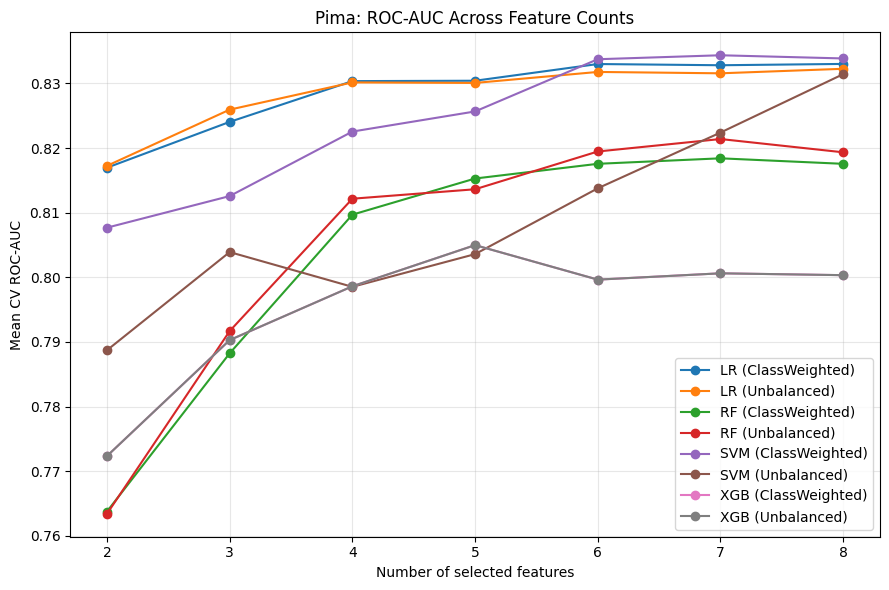

In [ ]:
# ============================================================
# STEP 12C — PIMA FEATURE-COUNT PROGRESSION
# ============================================================

import matplotlib.pyplot as plt

pima_progression = feature_progression[
    feature_progression["dataset"] == "Pima"
]

plt.figure(figsize=(9, 6))

for (model, balance), group in pima_progression.groupby(
    ["model", "balance"]
):
    group = group.sort_values("n_features")

    plt.plot(
        group["n_features"],
        group["roc_auc_mean"],
        marker="o",
        label=f"{model} ({balance})"
    )

plt.xlabel("Number of selected features")
plt.ylabel("Mean CV ROC-AUC")
plt.title("Pima: ROC-AUC Across Feature Counts")
plt.xticks(range(2, 9))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/pima_feature_progression_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

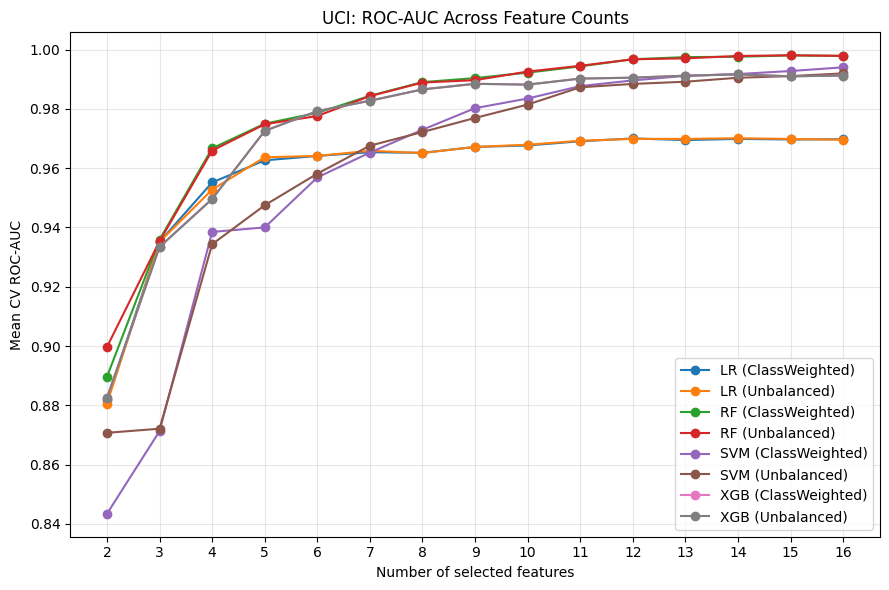

In [ ]:
# ============================================================
# STEP 12D — UCI FEATURE-COUNT PROGRESSION
# ============================================================

uci_progression = feature_progression[
    feature_progression["dataset"] == "UCI"
]

plt.figure(figsize=(9, 6))

for (model, balance), group in uci_progression.groupby(
    ["model", "balance"]
):
    group = group.sort_values("n_features")

    plt.plot(
        group["n_features"],
        group["roc_auc_mean"],
        marker="o",
        label=f"{model} ({balance})"
    )

plt.xlabel("Number of selected features")
plt.ylabel("Mean CV ROC-AUC")
plt.title("UCI: ROC-AUC Across Feature Counts")
plt.xticks(range(2, 17))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/uci_feature_progression_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# STEP 13A — SHAP SETUP
# ============================================================

import sys
import subprocess
import importlib.util

# ------------------------------------------------------------
# Install SHAP only if needed
# ------------------------------------------------------------
if importlib.util.find_spec("shap") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "shap"
    ])

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

# ------------------------------------------------------------
# Verify best RF configurations used for SHAP
# ------------------------------------------------------------
print("\nRF configurations for SHAP:")

print(
    best_by_model[
        best_by_model["model"] == "RF"
    ][
        [
            "dataset",
            "model",
            "balance",
            "n_features",
            "roc_auc_mean",
            "f1_mean"
        ]
    ].to_string(index=False)
)

SHAP version: 0.52.0

RF configurations for SHAP:
dataset model    balance  n_features  roc_auc_mean  f1_mean
   Pima    RF Unbalanced           7      0.821392 0.625128
    UCI    RF Unbalanced          15      0.998121 0.979201


In [ ]:
# ============================================================
# STEP 13B — PREPARE BEST RF MODELS FOR SHAP
# ============================================================

# Use the RF models already fitted during Step 11B
pima_rf = computational_models["Pima_RF"]
uci_rf = computational_models["UCI_RF"]

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def prepare_shap_data(pipeline, X, original_feature_names):
    """
    Reproduce the preprocessing already fitted inside the pipeline:
        imputer -> scaler -> RFE

    Returns:
        transformed data seen by RF
        selected original feature names
        original-scale selected data
    """

    imputer = pipeline.named_steps["imputer"]
    scaler = pipeline.named_steps["scaler"]
    rfe = pipeline.named_steps["rfe"]

    # Sequential transformation
    X_imputed = imputer.transform(X)
    X_scaled = scaler.transform(X_imputed)
    X_selected = rfe.transform(X_scaled)

    # Recover selected original feature names
    selected_mask = rfe.support_

    selected_names = [
        feature
        for feature, selected
        in zip(original_feature_names, selected_mask)
        if selected
    ]

    # Original-scale selected values for interpretation
    X_original_selected = X.loc[:, selected_names].copy()

    return (
        X_selected,
        selected_names,
        X_original_selected
    )


# ------------------------------------------------------------
# Pima
# ------------------------------------------------------------

pima_rf_test_transformed, \
pima_rf_features, \
pima_rf_test_original = prepare_shap_data(
    pima_rf,
    X_pima_test,
    pima_features
)

# ------------------------------------------------------------
# UCI
# ------------------------------------------------------------

uci_rf_test_transformed, \
uci_rf_features, \
uci_rf_test_original = prepare_shap_data(
    uci_rf,
    X_uci_test,
    uci_features
)

print("Pima RF selected features:")
for feature in pima_rf_features:
    print(" -", feature)

print("\nUCI RF selected features:")
for feature in uci_rf_features:
    print(" -", feature)

Pima RF selected features:
 - Pregnancies
 - Glucose
 - BloodPressure
 - Insulin
 - BMI
 - DiabetesPedigreeFunction
 - Age

UCI RF selected features:
 - Age
 - Gender
 - Polyuria
 - Polydipsia
 - sudden weight loss
 - weakness
 - Polyphagia
 - Genital thrush
 - visual blurring
 - Itching
 - Irritability
 - delayed healing
 - partial paresis
 - muscle stiffness
 - Alopecia


SHAP output type: <class 'numpy.ndarray'>
SHAP array shape: (154, 7, 2)

Positive-class SHAP shape: (154, 7)
Expected shape: (154, 7)

PIMA — GLOBAL SHAP IMPORTANCE
                 feature  mean_abs_shap
                 Glucose       0.137377
                     BMI       0.079570
                     Age       0.062890
DiabetesPedigreeFunction       0.043578
             Pregnancies       0.033385
                 Insulin       0.022523
           BloodPressure       0.014084


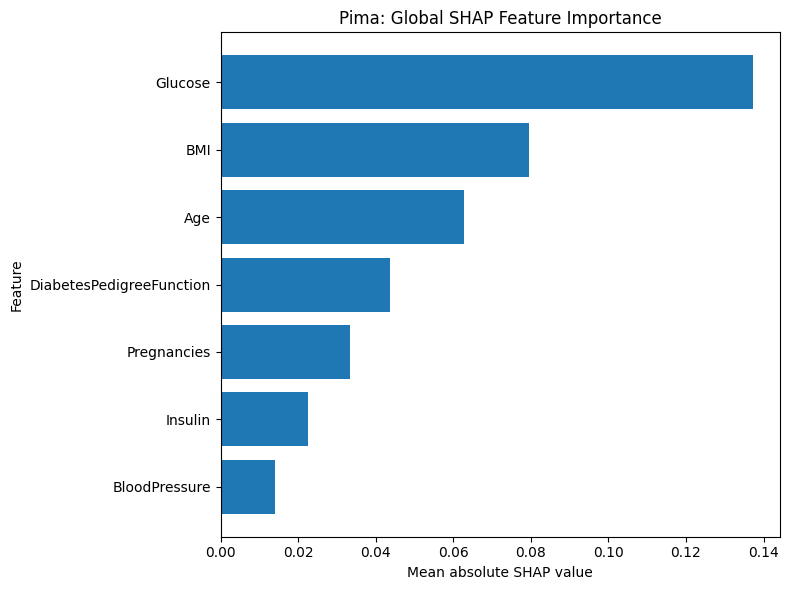

In [ ]:
# ============================================================
# STEP 13C — PIMA GLOBAL SHAP (CORRECTED)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ------------------------------------------------------------
# Create TreeExplainer
# ------------------------------------------------------------

explainer_pima = shap.TreeExplainer(
    pima_rf.named_steps["model"]
)

# ------------------------------------------------------------
# Calculate SHAP values
# ------------------------------------------------------------

shap_values_pima = explainer_pima.shap_values(
    pima_rf_test_transformed
)

# ------------------------------------------------------------
# Inspect SHAP shape
# ------------------------------------------------------------

print("SHAP output type:", type(shap_values_pima))

if isinstance(shap_values_pima, list):
    print("SHAP list length:", len(shap_values_pima))
    print("Class 0 shape:", np.asarray(shap_values_pima[0]).shape)
    print("Class 1 shape:", np.asarray(shap_values_pima[1]).shape)

else:
    print(
        "SHAP array shape:",
        np.asarray(shap_values_pima).shape
    )

# ------------------------------------------------------------
# Extract SHAP values for positive class
# ------------------------------------------------------------

shap_array = np.asarray(shap_values_pima)

if isinstance(shap_values_pima, list):

    # Older SHAP format:
    # [class_0_array, class_1_array]
    shap_values_pima_positive = np.asarray(
        shap_values_pima[1]
    )

elif shap_array.ndim == 3:

    # Newer SHAP format:
    # (samples, features, classes)
    shap_values_pima_positive = shap_array[:, :, 1]

elif shap_array.ndim == 2:

    # Already (samples, features)
    shap_values_pima_positive = shap_array

else:
    raise ValueError(
        f"Unexpected SHAP array shape: {shap_array.shape}"
    )

print(
    "\nPositive-class SHAP shape:",
    shap_values_pima_positive.shape
)

print(
    "Expected shape:",
    (
        len(X_pima_test),
        len(pima_rf_features)
    )
)

# ------------------------------------------------------------
# Verify dimensionality
# ------------------------------------------------------------

assert shap_values_pima_positive.ndim == 2

assert shap_values_pima_positive.shape == (
    len(X_pima_test),
    len(pima_rf_features)
), (
    f"Unexpected SHAP shape: "
    f"{shap_values_pima_positive.shape}"
)

# ------------------------------------------------------------
# Mean absolute SHAP importance
# ------------------------------------------------------------

pima_shap_importance = pd.DataFrame({
    "feature": pima_rf_features,
    "mean_abs_shap": np.abs(
        shap_values_pima_positive
    ).mean(axis=0)
})

pima_shap_importance = (
    pima_shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nPIMA — GLOBAL SHAP IMPORTANCE")
print("=" * 60)

print(
    pima_shap_importance.to_string(index=False)
)

# ------------------------------------------------------------
# Plot global SHAP importance
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.barh(
    pima_shap_importance["feature"],
    pima_shap_importance["mean_abs_shap"]
)

plt.gca().invert_yaxis()

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.title("Pima: Global SHAP Feature Importance")

plt.tight_layout()

plt.savefig(
    "/content/pima_global_shap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

SHAP output type: <class 'numpy.ndarray'>
SHAP array shape: (104, 15, 2)

Positive-class SHAP shape: (104, 15)
Expected shape: (104, 15)

UCI — GLOBAL SHAP IMPORTANCE
           feature  mean_abs_shap
          Polyuria       0.139092
        Polydipsia       0.124733
            Gender       0.079227
sudden weight loss       0.042311
   partial paresis       0.035108
          Alopecia       0.031339
           Itching       0.027895
        Polyphagia       0.026868
      Irritability       0.026160
               Age       0.020629
   visual blurring       0.017370
   delayed healing       0.014127
    Genital thrush       0.013872
          weakness       0.009784
  muscle stiffness       0.008282


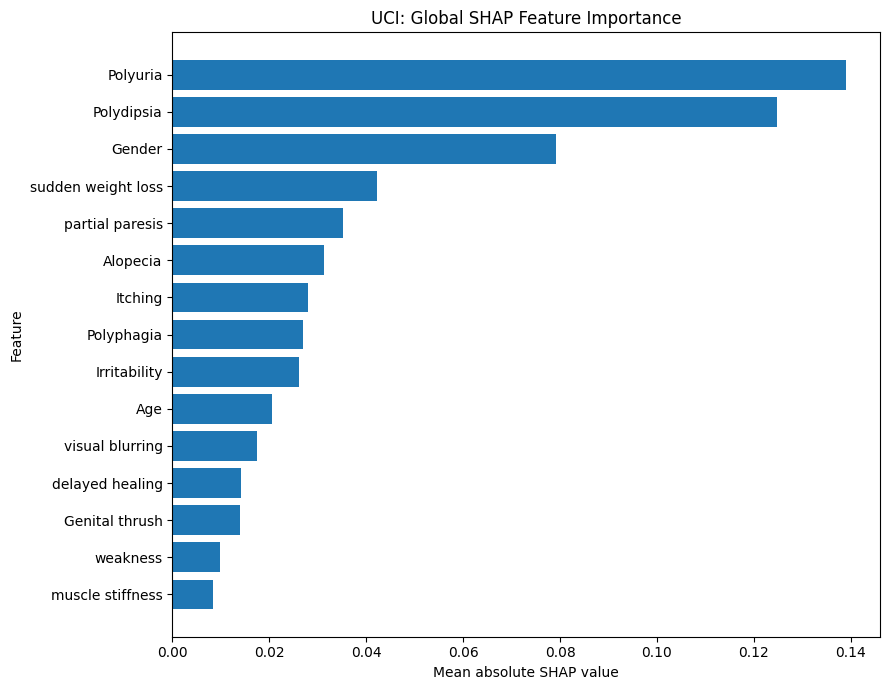

In [ ]:
# ============================================================
# STEP 13D — UCI GLOBAL SHAP (CORRECTED)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ------------------------------------------------------------
# Create TreeExplainer
# ------------------------------------------------------------

explainer_uci = shap.TreeExplainer(
    uci_rf.named_steps["model"]
)

# ------------------------------------------------------------
# Calculate SHAP values
# ------------------------------------------------------------

shap_values_uci = explainer_uci.shap_values(
    uci_rf_test_transformed
)

# ------------------------------------------------------------
# Inspect SHAP output
# ------------------------------------------------------------

print("SHAP output type:", type(shap_values_uci))

if isinstance(shap_values_uci, list):

    print("SHAP list length:", len(shap_values_uci))

    print(
        "Class 0 shape:",
        np.asarray(shap_values_uci[0]).shape
    )

    print(
        "Class 1 shape:",
        np.asarray(shap_values_uci[1]).shape
    )

else:

    print(
        "SHAP array shape:",
        np.asarray(shap_values_uci).shape
    )

# ------------------------------------------------------------
# Convert to NumPy array
# ------------------------------------------------------------

shap_array_uci = np.asarray(shap_values_uci)

# ------------------------------------------------------------
# Extract positive-class SHAP values
# ------------------------------------------------------------

if isinstance(shap_values_uci, list):

    # Older SHAP representation:
    # [class_0, class_1]
    shap_values_uci_positive = np.asarray(
        shap_values_uci[1]
    )

elif shap_array_uci.ndim == 3:

    # Newer SHAP representation:
    # (samples, features, classes)
    shap_values_uci_positive = shap_array_uci[:, :, 1]

elif shap_array_uci.ndim == 2:

    # Already in (samples, features) form
    shap_values_uci_positive = shap_array_uci

else:

    raise ValueError(
        f"Unexpected SHAP array shape: "
        f"{shap_array_uci.shape}"
    )

# ------------------------------------------------------------
# Verify final dimensions
# ------------------------------------------------------------

print(
    "\nPositive-class SHAP shape:",
    shap_values_uci_positive.shape
)

print(
    "Expected shape:",
    (
        len(X_uci_test),
        len(uci_rf_features)
    )
)

assert shap_values_uci_positive.ndim == 2

assert shap_values_uci_positive.shape == (
    len(X_uci_test),
    len(uci_rf_features)
), (
    f"Unexpected SHAP shape: "
    f"{shap_values_uci_positive.shape}"
)

# ------------------------------------------------------------
# Mean absolute SHAP importance
# ------------------------------------------------------------

uci_shap_importance = pd.DataFrame({
    "feature": uci_rf_features,
    "mean_abs_shap": np.abs(
        shap_values_uci_positive
    ).mean(axis=0)
})

uci_shap_importance = (
    uci_shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nUCI — GLOBAL SHAP IMPORTANCE")
print("=" * 60)

print(
    uci_shap_importance.to_string(index=False)
)

# ------------------------------------------------------------
# Plot global SHAP importance
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

plt.barh(
    uci_shap_importance["feature"],
    uci_shap_importance["mean_abs_shap"]
)

plt.gca().invert_yaxis()

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.title("UCI: Global SHAP Feature Importance")

plt.tight_layout()

plt.savefig(
    "/content/uci_global_shap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Pima local SHAP values: (7,)
Pima local feature values: (7,)
Pima number of features: 7

PIMA LOCAL SHAP EXPLANATION
Test observation index: 44
Actual class: 0
Predicted class: 1
Predicted probability: 0.6967


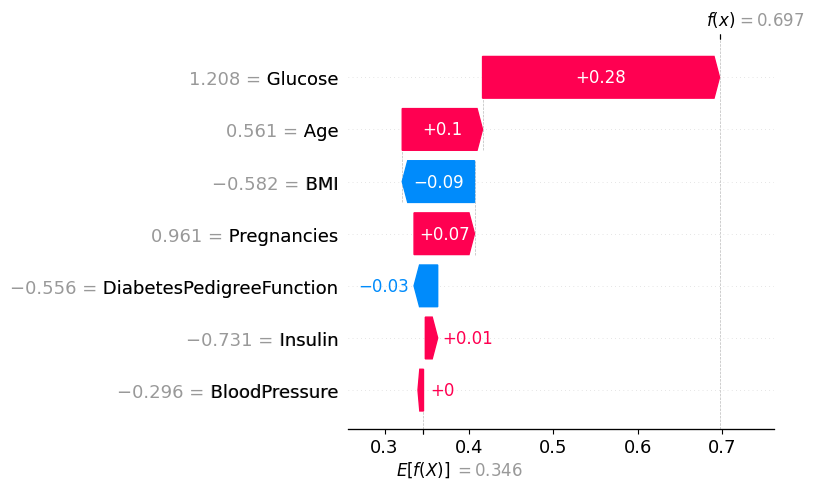


UCI local SHAP values: (15,)
UCI local feature values: (15,)
UCI number of features: 15

UCI LOCAL SHAP EXPLANATION
Test observation index: 332
Actual class: 0
Predicted class: 0
Predicted probability: 0.0233


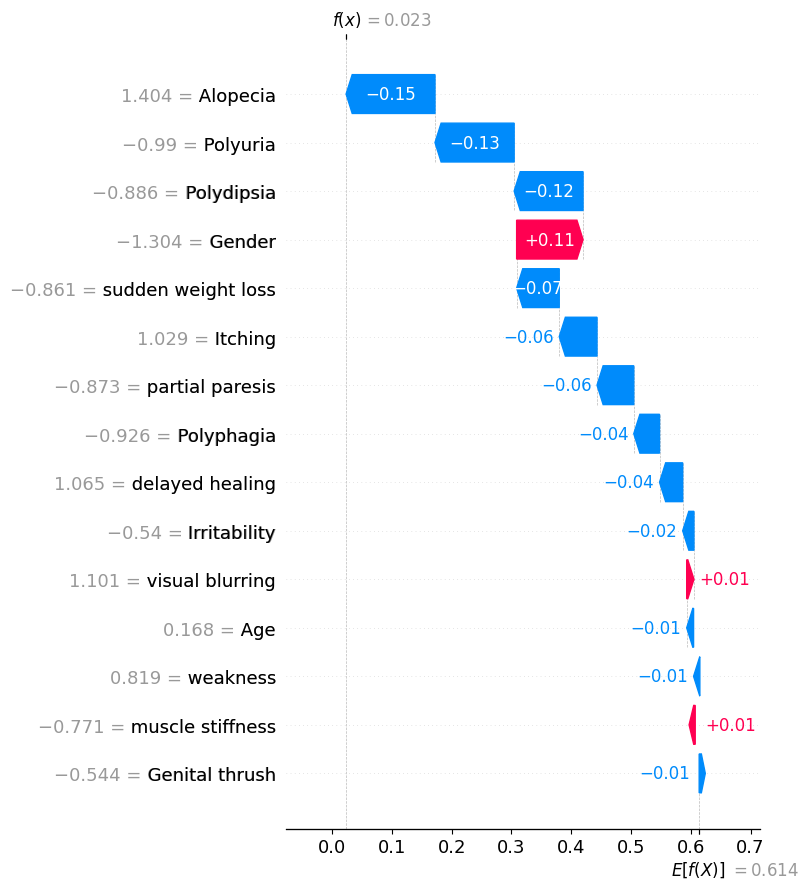

In [ ]:
# ============================================================
# STEP 13E — LOCAL SHAP EXPLANATIONS (CORRECTED)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ============================================================
# Helper function to obtain a scalar base value
# ============================================================

def get_positive_base_value(explainer):
    """
    Extract the expected value for class 1.
    Handles different SHAP versions/output formats.
    """

    base_value = explainer.expected_value
    base_array = np.asarray(base_value)

    if base_array.ndim == 0:
        return float(base_array)

    if base_array.size == 1:
        return float(base_array.ravel()[0])

    # Binary classification: class 1
    return float(base_array.ravel()[1])


# ============================================================
# PIMA LOCAL SHAP
# ============================================================

# Use the first held-out Pima observation
pima_row_position = 0
pima_index = X_pima_test.index[pima_row_position]

pima_base_value = get_positive_base_value(
    explainer_pima
)

pima_local_values = np.asarray(
    shap_values_pima_positive[pima_row_position]
).reshape(-1)

pima_local_data = np.asarray(
    pima_rf_test_transformed[pima_row_position]
).reshape(-1)

# Verify dimensions
print("Pima local SHAP values:",
      pima_local_values.shape)

print("Pima local feature values:",
      pima_local_data.shape)

print("Pima number of features:",
      len(pima_rf_features))

assert len(pima_local_values) == len(pima_rf_features)
assert len(pima_local_data) == len(pima_rf_features)

# Build explanation
pima_local_explanation = shap.Explanation(
    values=pima_local_values,
    base_values=pima_base_value,
    data=pima_local_data,
    feature_names=pima_rf_features
)

# Prediction information
pima_actual = int(
    y_pima_test.iloc[pima_row_position]
)

pima_prediction = int(
    pima_rf.predict(
        X_pima_test.iloc[[pima_row_position]]
    )[0]
)

pima_probability = float(
    pima_rf.predict_proba(
        X_pima_test.iloc[[pima_row_position]]
    )[0, 1]
)

print("\n" + "=" * 70)
print("PIMA LOCAL SHAP EXPLANATION")
print("=" * 70)

print("Test observation index:", pima_index)
print("Actual class:", pima_actual)
print("Predicted class:", pima_prediction)
print("Predicted probability:", round(pima_probability, 4))

# Waterfall plot
plt.figure(figsize=(9, 7))

shap.plots.waterfall(
    pima_local_explanation,
    max_display=len(pima_rf_features),
    show=False
)

plt.tight_layout()

plt.savefig(
    "/content/pima_local_shap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# UCI LOCAL SHAP
# ============================================================

# Use the first held-out UCI observation
uci_row_position = 0
uci_index = X_uci_test.index[uci_row_position]

uci_base_value = get_positive_base_value(
    explainer_uci
)

uci_local_values = np.asarray(
    shap_values_uci_positive[uci_row_position]
).reshape(-1)

uci_local_data = np.asarray(
    uci_rf_test_transformed[uci_row_position]
).reshape(-1)

# Verify dimensions
print("\nUCI local SHAP values:",
      uci_local_values.shape)

print("UCI local feature values:",
      uci_local_data.shape)

print("UCI number of features:",
      len(uci_rf_features))

assert len(uci_local_values) == len(uci_rf_features)
assert len(uci_local_data) == len(uci_rf_features)

# Build explanation
uci_local_explanation = shap.Explanation(
    values=uci_local_values,
    base_values=uci_base_value,
    data=uci_local_data,
    feature_names=uci_rf_features
)

# Prediction information
uci_actual = int(
    y_uci_test.iloc[uci_row_position]
)

uci_prediction = int(
    uci_rf.predict(
        X_uci_test.iloc[[uci_row_position]]
    )[0]
)

uci_probability = float(
    uci_rf.predict_proba(
        X_uci_test.iloc[[uci_row_position]]
    )[0, 1]
)

print("\n" + "=" * 70)
print("UCI LOCAL SHAP EXPLANATION")
print("=" * 70)

print("Test observation index:", uci_index)
print("Actual class:", uci_actual)
print("Predicted class:", uci_prediction)
print("Predicted probability:", round(uci_probability, 4))

# Waterfall plot
plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    uci_local_explanation,
    max_display=len(uci_rf_features),
    show=False
)

plt.tight_layout()

plt.savefig(
    "/content/uci_local_shap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# STEP 13F — SAVE ALL SHAP RESULTS (CORRECTED)
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# Save global SHAP importance tables
# ------------------------------------------------------------

pima_shap_importance.to_csv(
    "/content/pima_shap_global_importance.csv",
    index=False
)

uci_shap_importance.to_csv(
    "/content/uci_shap_global_importance.csv",
    index=False
)

# ------------------------------------------------------------
# Save selected RF feature lists
# ------------------------------------------------------------

pima_rf_feature_df = pd.DataFrame({
    "dataset": "Pima",
    "feature": pima_rf_features
})

uci_rf_feature_df = pd.DataFrame({
    "dataset": "UCI",
    "feature": uci_rf_features
})

rf_feature_df = pd.concat(
    [
        pima_rf_feature_df,
        uci_rf_feature_df
    ],
    ignore_index=True
)

rf_feature_df.to_csv(
    "/content/rf_shap_selected_features.csv",
    index=False
)

# ------------------------------------------------------------
# Save local SHAP numerical contributions
# ------------------------------------------------------------

pima_local_df = pd.DataFrame({
    "feature": pima_rf_features,
    "shap_value": pima_local_values,
    "model_input_value": pima_local_data
})

pima_local_df["dataset"] = "Pima"
pima_local_df["test_index"] = pima_index
pima_local_df["actual_class"] = pima_actual
pima_local_df["predicted_class"] = pima_prediction
pima_local_df["predicted_probability"] = pima_probability

uci_local_df = pd.DataFrame({
    "feature": uci_rf_features,
    "shap_value": uci_local_values,
    "model_input_value": uci_local_data
})

uci_local_df["dataset"] = "UCI"
uci_local_df["test_index"] = uci_index
uci_local_df["actual_class"] = uci_actual
uci_local_df["predicted_class"] = uci_prediction
uci_local_df["predicted_probability"] = uci_probability

local_shap_df = pd.concat(
    [
        pima_local_df,
        uci_local_df
    ],
    ignore_index=True
)

local_shap_df.to_csv(
    "/content/local_shap_results.csv",
    index=False
)

# ------------------------------------------------------------
# Verify files
# ------------------------------------------------------------

files_to_check = [
    "/content/pima_shap_global_importance.csv",
    "/content/uci_shap_global_importance.csv",
    "/content/rf_shap_selected_features.csv",
    "/content/local_shap_results.csv",
    "/content/pima_global_shap.png",
    "/content/uci_global_shap.png",
    "/content/pima_local_shap.png",
    "/content/uci_local_shap.png"
]

print("\n" + "=" * 70)
print("SHAP OUTPUT FILES")
print("=" * 70)

for path in files_to_check:
    status = "✓ EXISTS" if os.path.exists(path) else "✗ MISSING"
    print(f"{os.path.basename(path):45s} {status}")

print("\n✅ SHAP results saved successfully.")


SHAP OUTPUT FILES
pima_shap_global_importance.csv               ✓ EXISTS
uci_shap_global_importance.csv                ✓ EXISTS
rf_shap_selected_features.csv                 ✓ EXISTS
local_shap_results.csv                        ✓ EXISTS
pima_global_shap.png                          ✓ EXISTS
uci_global_shap.png                           ✓ EXISTS
pima_local_shap.png                           ✓ EXISTS
uci_local_shap.png                            ✓ EXISTS

✅ SHAP results saved successfully.


In [ ]:
# ============================================================
# STEP 14 — CREATE PAPER-READY RESULT TABLES
# ============================================================

# ------------------------------------------------------------
# Table II — Best CV configuration for each model
# ------------------------------------------------------------

table2_cv = best_by_model[
    [
        "dataset",
        "model",
        "balance",
        "n_features",
        "roc_auc_mean",
        "roc_auc_std",
        "f1_mean",
        "f1_std",
        "sensitivity_mean",
        "specificity_mean",
        "pr_auc_mean",
        "accuracy_mean"
    ]
].copy()

# ------------------------------------------------------------
# Table III — Final held-out test results
# ------------------------------------------------------------

table3_test = final_test_df[
    [
        "dataset",
        "model",
        "balance",
        "n_features",
        "accuracy",
        "f1",
        "sensitivity",
        "specificity",
        "roc_auc",
        "pr_auc",
        "tn",
        "fp",
        "fn",
        "tp"
    ]
].copy()

# ------------------------------------------------------------
# Table IV — Computational efficiency
# ------------------------------------------------------------

table4_computational = computational_df[
    [
        "dataset",
        "model",
        "balance",
        "n_features",
        "cv_roc_auc",
        "train_time_s",
        "inference_time_per_sample_s",
        "model_size_kb"
    ]
].copy()

# ------------------------------------------------------------
# Table V-A — Pima SHAP
# ------------------------------------------------------------

table5_pima_shap = pima_shap_importance.copy()

# ------------------------------------------------------------
# Table V-B — UCI SHAP
# ------------------------------------------------------------

table5_uci_shap = uci_shap_importance.copy()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

table2_cv.to_csv(
    "/content/table2_best_cv_models.csv",
    index=False
)

table3_test.to_csv(
    "/content/table3_final_test_results.csv",
    index=False
)

table4_computational.to_csv(
    "/content/table4_computational_efficiency.csv",
    index=False
)

table5_pima_shap.to_csv(
    "/content/table5_pima_shap.csv",
    index=False
)

table5_uci_shap.to_csv(
    "/content/table5_uci_shap.csv",
    index=False
)

print("Paper-ready tables saved successfully.\n")

print("TABLE II — BEST CV MODELS")
display(table2_cv)

print("\nTABLE III — FINAL TEST RESULTS")
display(table3_test)

print("\nTABLE IV — COMPUTATIONAL EFFICIENCY")
display(table4_computational)

print("\nTABLE V-A — PIMA SHAP")
display(table5_pima_shap)

print("\nTABLE V-B — UCI SHAP")
display(table5_uci_shap)

Paper-ready tables saved successfully.

TABLE II — BEST CV MODELS


,dataset,model,balance,n_features,roc_auc_mean,roc_auc_std,f1_mean,f1_std,sensitivity_mean,specificity_mean,pr_auc_mean,accuracy_mean
0,Pima,LR,ClassWeighted,8,0.833012,0.035518,0.676931,0.046299,0.724385,0.77650,0.735092,0.758275
1,Pima,RF,Unbalanced,7,0.821392,0.038634,0.625128,0.057575,0.578671,0.85400,0.718469,0.757982
2,Pima,SVM,ClassWeighted,7,0.834351,0.035877,0.666044,0.056892,0.730808,0.75000,0.720591,0.743284
3,Pima,XGB,ClassWeighted,5,0.804980,0.033894,0.624167,0.043656,0.599136,0.83000,0.691615,0.749511
4,UCI,LR,Unbalanced,14,0.970128,0.016120,0.942716,0.022686,0.939849,0.91375,0.983894,0.929816
5,UCI,RF,Unbalanced,15,0.998121,0.001632,0.979201,0.014356,0.977360,0.97000,0.998815,0.974527
6,UCI,SVM,ClassWeighted,16,0.994046,0.007006,0.964553,0.016898,0.951554,0.96625,0.995910,0.957223
7,UCI,XGB,ClassWeighted,14,0.991658,0.006820,0.977539,0.016152,0.974238,0.97000,0.995166,0.972599



TABLE III — FINAL TEST RESULTS


,dataset,model,balance,n_features,accuracy,f1,sensitivity,specificity,roc_auc,pr_auc,tn,fp,fn,tp
0,Pima,SVM,ClassWeighted,7,0.720779,0.656000,0.759259,0.700,0.805278,0.644792,70,30,13,41
1,UCI,RF,Unbalanced,15,0.980769,0.984375,0.984375,0.975,0.998437,0.999015,39,1,1,63



TABLE IV — COMPUTATIONAL EFFICIENCY


,dataset,model,balance,n_features,cv_roc_auc,train_time_s,inference_time_per_sample_s,model_size_kb
0,Pima,LR,ClassWeighted,8,0.833012,0.019644,0.000029,2.532227
1,Pima,RF,Unbalanced,7,0.821392,2.999062,0.000611,8196.679688
2,Pima,SVM,ClassWeighted,7,0.834351,0.209864,0.000075,56.430664
3,Pima,XGB,ClassWeighted,5,0.804980,0.778349,0.000034,695.143555
4,UCI,LR,Unbalanced,14,0.970128,0.018164,0.000030,3.046875
5,UCI,RF,Unbalanced,15,0.998121,2.157593,0.000773,3574.795898
6,UCI,SVM,ClassWeighted,16,0.994046,0.081574,0.000073,33.703125
7,UCI,XGB,ClassWeighted,14,0.991658,0.639544,0.000090,613.161133



TABLE V-A — PIMA SHAP


,feature,mean_abs_shap
0,Glucose,0.137377
1,BMI,0.079570
2,Age,0.062890
3,DiabetesPedigreeFunction,0.043578
4,Pregnancies,0.033385
5,Insulin,0.022523
6,BloodPressure,0.014084



TABLE V-B — UCI SHAP


,feature,mean_abs_shap
0,Polyuria,0.139092
1,Polydipsia,0.124733
2,Gender,0.079227
3,sudden weight loss,0.042311
4,partial paresis,0.035108
5,Alopecia,0.031339
6,Itching,0.027895
7,Polyphagia,0.026868
8,Irritability,0.026160
9,Age,0.020629


In [ ]:
# ============================================================
# STEP 15 — CREATE MASTER PAPER RESULTS FILE
# ============================================================

# ------------------------------------------------------------
# Final selected models
# ------------------------------------------------------------

master_selected = best_configs[
    [
        "dataset",
        "model",
        "balance",
        "n_features",
        "roc_auc_mean",
        "roc_auc_std",
        "f1_mean",
        "f1_std",
        "sensitivity_mean",
        "sensitivity_std",
        "specificity_mean",
        "pr_auc_mean",
        "accuracy_mean"
    ]
].copy()

master_selected["result_type"] = "Final CV-selected configuration"

# ------------------------------------------------------------
# Final held-out test results
# ------------------------------------------------------------

master_test = final_test_df[
    [
        "dataset",
        "model",
        "balance",
        "n_features",
        "accuracy",
        "f1",
        "sensitivity",
        "specificity",
        "roc_auc",
        "pr_auc",
        "tn",
        "fp",
        "fn",
        "tp"
    ]
].copy()

master_test["result_type"] = "Final held-out test"

# ------------------------------------------------------------
# Computational profiling
# ------------------------------------------------------------

master_compute = computational_df[
    [
        "dataset",
        "model",
        "balance",
        "n_features",
        "cv_roc_auc",
        "train_time_s",
        "inference_time_per_sample_s",
        "model_size_kb"
    ]
].copy()

master_compute["result_type"] = "Computational profile"

# ------------------------------------------------------------
# Save separately and print
# ------------------------------------------------------------

master_selected.to_csv(
    "/content/master_final_cv_results.csv",
    index=False
)

master_test.to_csv(
    "/content/master_final_test_results.csv",
    index=False
)

master_compute.to_csv(
    "/content/master_computational_results.csv",
    index=False
)

print("MASTER FILES SAVED")
print("1. /content/master_final_cv_results.csv")
print("2. /content/master_final_test_results.csv")
print("3. /content/master_computational_results.csv")

print("\nFINAL CV SELECTION")
display(master_selected)

print("\nFINAL TEST RESULTS")
display(master_test)

print("\nCOMPUTATIONAL RESULTS")
display(master_compute)

MASTER FILES SAVED
1. /content/master_final_cv_results.csv
2. /content/master_final_test_results.csv
3. /content/master_computational_results.csv

FINAL CV SELECTION


,dataset,model,balance,n_features,roc_auc_mean,roc_auc_std,f1_mean,f1_std,sensitivity_mean,sensitivity_std,specificity_mean,pr_auc_mean,accuracy_mean,result_type
0,Pima,SVM,ClassWeighted,7,0.834351,0.035877,0.666044,0.056892,0.730808,0.065219,0.75,0.720591,0.743284,Final CV-selected configuration
1,UCI,RF,Unbalanced,15,0.998121,0.001632,0.979201,0.014356,0.977360,0.020807,0.97,0.998815,0.974527,Final CV-selected configuration



FINAL TEST RESULTS


,dataset,model,balance,n_features,accuracy,f1,sensitivity,specificity,roc_auc,pr_auc,tn,fp,fn,tp,result_type
0,Pima,SVM,ClassWeighted,7,0.720779,0.656000,0.759259,0.700,0.805278,0.644792,70,30,13,41,Final held-out test
1,UCI,RF,Unbalanced,15,0.980769,0.984375,0.984375,0.975,0.998437,0.999015,39,1,1,63,Final held-out test



COMPUTATIONAL RESULTS


,dataset,model,balance,n_features,cv_roc_auc,train_time_s,inference_time_per_sample_s,model_size_kb,result_type
0,Pima,LR,ClassWeighted,8,0.833012,0.019644,0.000029,2.532227,Computational profile
1,Pima,RF,Unbalanced,7,0.821392,2.999062,0.000611,8196.679688,Computational profile
2,Pima,SVM,ClassWeighted,7,0.834351,0.209864,0.000075,56.430664,Computational profile
3,Pima,XGB,ClassWeighted,5,0.804980,0.778349,0.000034,695.143555,Computational profile
4,UCI,LR,Unbalanced,14,0.970128,0.018164,0.000030,3.046875,Computational profile
5,UCI,RF,Unbalanced,15,0.998121,2.157593,0.000773,3574.795898,Computational profile
6,UCI,SVM,ClassWeighted,16,0.994046,0.081574,0.000073,33.703125,Computational profile
7,UCI,XGB,ClassWeighted,14,0.991658,0.639544,0.000090,613.161133,Computational profile


###  PIMA INDIANS DIABETES DATASET

The Pima Indian Diabetes Dataset, originally from the National Institute of Diabetes and Digestive and Kidney Diseases, contains information of 768 women from a population near Phoenix, Arizona, USA. The outcome tested was Diabetes, 258 tested positive and 500 tested negative. Therefore, there is one target (dependent) variable and the following attributes (TYNECKI, 2018):


	Pregnancies (number of times pregnant),

	Oral glucose tolerance test - OGTT (two hour plasma glucose concentration after 75g anhydrous glucose in mg/dl),

	Blood Pressure (Diastolic Blood Pressure in mmHg),

	Skin Thickness (Triceps skin fold thickness in mm),

	Insulin (2 h serum insulin in mu U/ml),

	BMI (Body Mass Index in kg/m<sup>2</sup>),

	Age (years),

	Pedigree Diabetes Function ('function that represents how likely they are to get the disease by extrapolating from their ancestor’s history')

### PIMA INDIANS AND DIABETES

Pima are descendants of people that inhabited the Sonoran desert and Sierra Madre areas for centuries. Around 300 B.C. they moved to Gila River Valley at the time  in Mexico, but region that was acquired by the United States in 1853. A Pima reservation was created in Arizona in 1959 and they adapted to their desert homeland by directing water to support a subsistence agriculture. Around 1900 the number of population of white settlers increased and a diversion of the water happened. That had an impact of Pima's food intake and way of life. Pima Indians used to farm sustained through physical labour to a little labour and scarce of food. As a consequence they food intake became high in fat and their lifestyle was mainly sedentary. That resulted in development of diabetes among the Arizona Pimas, and it drawed attention as they had the highest recorded prevalence and incidence of type 2 diabetes (T2DM) of any geographically-defined population (SCHULZ et al, 2015).
The Pima population has been under study by the National Institute of Diabetes and Digestive and Kidney Diseases at intervals of 2 years since 1965. As epidemiological evidence indicates that T2DM results from interaction of genetic and environmental factors, the Pima Indians Diabetes Dataset includes information about attributes that could and should be related to the onset of diabetes and its future complications.

### TRICEPS SKIN FOLD THICKNESS

Chandra-Selvi at al (2016) defined adipose tissue as a <i>'loose connective tissue composed mainly of adipocytes that has an unlimited growth potential at any stage of life, excess of adipose tissue predisposes to many diseases-development of insulin resistance'</i>. Their study found that the skinfold thickness gradually decreased in diabetic patients as the duration of disease increased. However, the Pima Indians Diabetes Dataset does not provide information on the duration of the Diabetes.  The researchers discussed the results and concluded that in diabetic patients, there is an efflux of free fatty acids from the adipose tissue, resulting in a decrease of skin fold thickness as the duration of disease increases (CHANDRA-SELVI at al, 2016).
Neverthless, there is still very limited prospective information evaluating the relationship of skinfold thickness with incident T2DM (RUIZ-ALEJOS et al, 2020).
Triceps skinfold thickness in millimeters for females aged 20 and over and number of examined persons, mean, standard error of the mean, and selected percentiles, by race and ethnicity and age: United States, 2007–2010 (FRYAR et al, 2012).

<a href="https://ibb.co/4NDNNx1"><img src="https://i.ibb.co/KyQyyHK/table-triceps-skin-fold.png" alt="table-triceps-skin-fold" border="0"></a>

### OBESITY AND DIABETES

Obesity, assessed by Body Mass Index (BMI), is intimately associated with diabetes and its impact on the development of T2DM has been largely described in large cohort prospective studies (VAN GAAL and SCHEEN, 2015; WILDING, 2014; RUIZ-ALEJOS et al, 2020). In fact, most of the individuals with T2DM are overweight or obese <sup>5</sup>.  Despite the link between obesity and T2DM not all obese develops diabetes and not all diabetics are obese people. Diabetic lean people probably have a stronger genetic component for T2DM than overweight and obese individuals (WILDING, 2014).
Accordingly to Ruiz-Alejos and col (2020) 'there is no specific recommendation about the use of an anthropometric measurement as a marker for T2DM risk prediction besides BMI and waist circumference'. Unfortunately the waist circumference is a measurement not included in the Pima Indians Diabetes Dataset.
BMI provides a simple, yet accurate method for indicating nutritional status in adults (as it can be seem in the Table below), and it can be calculated by dividing the individual's weight (in kg) by the square of their height (in metres).
<img src="https://i.ibb.co/647ZL2X/bmi.png" alt="bmi" border="0">

<img src="https://i.ibb.co/HTqTfdr/WHO-Europe-Nutrition-Body-mass-index-BMI.png" alt="WHO-Europe-Nutrition-Body-mass-index-BMI" border="0">
Table. Nutritional Status. Source: World Health Organization.

## OBJECTIVE

The objective of this project is:
1. Analyse the dataset under the point of view of a Dietitian.
2. Apply machine learning techniques resulting in bridging the gap between datasets and human knowledge.

In [ ]:
#Load packages

import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.model_selection as mod
import sklearn.neighbors as nei
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import LeaveOneOut
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report, precision_recall_curve, average_precision_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.cross_validation import cross_val_score
from sklearn.feature_selection import RFECV
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import operator
%matplotlib inline

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\cross_validation.py:41: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\compat\pandas.py:56: FutureWarning: The pandas.core.datetools module is deprecated and will be removed in a future version. Please use the pandas.tseries module instead.
  from pandas.core import datetools


In [ ]:
url="https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"

In [ ]:
#Load CSV file using Pandas

pima = pd.read_csv(url)

#### Check the DataFrame & Descriptive Statistics and Analysis of Pima Indians Dataset

In [ ]:
# Check dimension of the DataFrame

pima.shape

(768, 9)

In [ ]:
# Check the type of 'pima'
type(pima)

pandas.core.frame.DataFrame

In [ ]:
# Get row indices

pima_row_idx = pima.index
pima_row_idx

RangeIndex(start=0, stop=768, step=1)

In [ ]:
# Get the column names

pima_col_idx = pima.columns
pima_col_idx

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
# Get data type for each attribute

pima.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [ ]:
# Check the first 5 rows

pima.head (5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Check missing values

pima.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
# Create Nutritional status column

Nutritional_status = pd.Series([])

In [ ]:
# Nutritional status based on BMI

for i in range(len(pima)):
    if pima['BMI'][i] == 0.0:
        Nutritional_status[i]="NA"

    elif pima['BMI'][i] < 18.5:
        Nutritional_status[i]="Underweight"

    elif pima['BMI'][i] < 25:
        Nutritional_status[i]="Normal"

    elif pima['BMI'][i] >= 25 and pima['BMI'][i] < 30:
        Nutritional_status[i]="Overweight"

    elif pima['BMI'][i] >= 30:
        Nutritional_status[i]="Obese"

    else:
        Nutritional_status[i]= pima['BMI'][i]

In [ ]:
# Insert new column - Nutritional Status
pima.insert(6, "Nutritional Status", Nutritional_status)

In [ ]:
# Check df containing new column
pima.head (5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Nutritional Status,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,Obese,0.627,50,1
1,1,85,66,29,0,26.6,Overweight,0.351,31,0
2,8,183,64,0,0,23.3,Normal,0.672,32,1
3,1,89,66,23,94,28.1,Overweight,0.167,21,0
4,0,137,40,35,168,43.1,Obese,2.288,33,1


In [ ]:
pima['Nutritional Status'].value_counts()

Obese          472
Overweight     179
Normal         102
NA              11
Underweight      4
Name: Nutritional Status, dtype: int64

##### 11 women don't have information about BMI. Only 106 of 758 women have normal weight. Most of the women present overweight or obesity.

In [ ]:
# Create OGTT_Interpretation (Interpretation of Glucose level) column

OGTT_Interpretation = pd.Series([])

In [ ]:
# Interpretation of OGTT (Glucose) - using OGTT levels recommended by DIABETES UK (2019)

for i in range(len(pima)):
    if pima['Glucose'][i] == 0.0:
        OGTT_Interpretation [i]="NA"

    elif pima['Glucose'][i] <= 140:
        OGTT_Interpretation [i]="Normal"

    elif pima['Glucose'][i] > 140 & pima['Glucose'][i] <= 198:
        OGTT_Interpretation [i]="Impaired Glucose Tolerance"

    elif pima['Glucose'][i] > 198:
        OGTT_Interpretation[i]="Diabetic Level"

    else:
        OGTT_Interpretation [i]= pima['Glucose'][i]

In [ ]:
# Insert new column - Glucose Result
pima.insert(2, "Glucose Result", OGTT_Interpretation)

In [ ]:
pima['Glucose Result'].value_counts()

Normal                        571
Impaired Glucose Tolerance    192
NA                              5
Name: Glucose Result, dtype: int64

##### Not a single individual from the sample showed OGTT result at "Diabetic levels". Would be interesting to calculate HOMA-IR to get information about insulin resistance of the sample. *****DISCUSS HERE ABOUT GLUCOSE INTOLERANCE AND INSULIN RESISTANCE********

In [ ]:
Impaired_Glucose_Tolerance_Diabetic = ((pima ['Glucose'] > 140 ) & (pima ['Glucose'] <= 198) & (pima ['Outcome'] == 1)).sum()
Impaired_Glucose_Tolerance_Diabetic

131

##### Not every women with impaired glucose tolerance have diabetes. That can show that the ones with impaired glucose tolerance might be in risk of developing diabetes or are diabetic, but not already diagnosed.

In [ ]:
Normal_Glucose_Diabetic = ((pima ['Glucose'] != 0 ) & (pima ['Glucose'] <= 140) & (pima ['Outcome'] == 1)).sum()
Normal_Glucose_Diabetic

134

##### Half of the diabetic women showed normal glucose level. Information regarding drug therapy is needed.

In [ ]:
# Create Percentile of skin thickness column

Percentile_skin_thickness = pd.Series([])

In [ ]:
# Check how many women are 80 or older (the Percentile skin thickeness depend of skin fold and age)

pima['Age'].value_counts()

22    72
21    63
25    48
24    46
23    38
28    35
26    33
27    32
29    29
31    24
41    22
30    21
37    19
42    18
33    17
32    16
36    16
38    16
45    15
34    14
40    13
43    13
46    13
39    12
35    10
50     8
44     8
51     8
52     8
58     7
47     6
54     6
57     5
60     5
48     5
49     5
53     5
55     4
62     4
63     4
66     4
56     3
59     3
65     3
67     3
61     2
69     2
72     1
64     1
68     1
70     1
81     1
Name: Age, dtype: int64

In [ ]:
#  Check skin fold thickness Percentile

for i in range(len(pima)):


    if pima["Age"][i] >= 20.0 and pima["Age"][i] <= 79.0:

        if pima["SkinThickness"][i] == 0.0:
            Percentile_skin_thickness[i]=" 0 NA"

        elif pima["SkinThickness"][i] < 11.9:
            Percentile_skin_thickness[i]="1 <P5th"

        elif pima["SkinThickness"][i] == 11.9:
            Percentile_skin_thickness[i]="2 P5th"

        elif pima["SkinThickness"][i] > 11.9 and pima["SkinThickness"][i] < 14.0:
            Percentile_skin_thickness[i]="3 P5th - P10th"

        elif pima["SkinThickness"][i] == 14.0:
            Percentile_skin_thickness[i]="4 P10th"

        elif pima["SkinThickness"][i] > 14.0 and  pima["SkinThickness"][i] < 15.8:
            Percentile_skin_thickness[i]="5 P10th - P15th"

        elif pima["SkinThickness"][i] == 15.8:
            Percentile_skin_thickness[i]="6 P15th"

        elif pima["SkinThickness"][i] > 15.8 and pima["SkinThickness"][i] < 18.0:
            Percentile_skin_thickness[i]="7 P15th - P25th"

        elif pima["SkinThickness"][i] == 18.0:
            Percentile_skin_thickness[i]="8 P25th"

        elif pima["SkinThickness"][i] > 18.0 and pima["SkinThickness"][i] < 23.5:
            Percentile_skin_thickness[i]="9 P25th - P50th"

        elif pima["SkinThickness"][i] == 23.5:
            Percentile_skin_thickness[i]="10 P50th"

        elif pima["SkinThickness"][i] > 23.5 and pima["SkinThickness"][i] < 29.0:
            Percentile_skin_thickness[i]="11 P50th - P75th"

        elif pima["SkinThickness"][i] == 29.0:
            Percentile_skin_thickness[i]="12 P75th"

        elif pima["SkinThickness"][i] > 29.0 and pima["SkinThickness"][i] < 31.9:
            Percentile_skin_thickness[i]="13 P75th - P85th"

        elif pima["SkinThickness"][i] == 31.9:
            Percentile_skin_thickness[i]="14 P85th"

        elif pima["SkinThickness"][i] > 31.9 and pima["SkinThickness"][i] < 33.7:
            Percentile_skin_thickness[i]="15 P85th - P90th"

        elif pima["SkinThickness"][i] == 33.7:
            Percentile_skin_thickness[i]="16 P90th"

        elif pima["SkinThickness"][i] > 33.7 and pima["SkinThickness"][i] < 35.9:
            Percentile_skin_thickness[i]="17 P90th - P95th"

        elif pima["SkinThickness"][i] == 35.9:
            Percentile_skin_thickness[i]="18 P95th"

        elif pima["SkinThickness"][i] > 35.9:
            Percentile_skin_thickness[i]="19 >P95th"

    elif pima["Age"][i] >= 80.0:  #Only 1 woman is 81 years old
        if  pima["SkinThickness"][i] > 31.7:
            Percentile_skin_thickness[i]="20 >P95th"


<i>**Note**</i>: As I have 2 >P95 I chose to add numbers in front of each percentile to easily visualize which >P95 it belonged.

In [ ]:
# Insert new column - Percentile of skin thickness

pima.insert(4, "Percentile skin thickness", Percentile_skin_thickness)

In [ ]:
# Check the first 5 rows

pima.head(5)

,Pregnancies,Glucose,Glucose Result,BloodPressure,Percentile skin thickness,SkinThickness,Insulin,BMI,Nutritional Status,DiabetesPedigreeFunction,Age,Outcome
0,6,148,Impaired Glucose Tolerance,72,17 P90th - P95th,35,0,33.6,Obese,0.627,50,1
1,1,85,Normal,66,12 P75th,29,0,26.6,Overweight,0.351,31,0
2,8,183,Impaired Glucose Tolerance,64,0 NA,0,0,23.3,Normal,0.672,32,1
3,1,89,Normal,66,9 P25th - P50th,23,94,28.1,Overweight,0.167,21,0
4,0,137,Normal,40,17 P90th - P95th,35,168,43.1,Obese,2.288,33,1


##### It looks like the Percentile of the triceps skin fold thickness can predict the Nutritional Status.

In [ ]:
# Check number of women x Percentile of skin thickness

pima['Percentile skin thickness'].value_counts()

 0 NA               227
19 >P95th           145
11 P50th - P75th     87
9 P25th - P50th      79
15 P85th - P90th     50
13 P75th - P85th     46
17 P90th - P95th     23
8 P25th              20
7 P15th - P25th      20
3 P5th - P10th       18
12 P75th             17
1 <P5th              15
5 P10th - P15th      14
4 P10th               6
20 >P95th             1
Name: Percentile skin thickness, dtype: int64

##### 227 women don't have information regarding skin fold. Most of the sample have Percentile of skin thickness greater than 95th. 53 women had value below P15 indicating that they might be malnourished. Only one woman is 80 years old or older and she presents a Percentile of skin thickness greater than 95th.

In [ ]:
diabetic_malnourished_st = ((pima ['SkinThickness'] < 15.8) & (pima ['Outcome'] == 1)).sum()
diabetic_malnourished_st

94

In [ ]:
diabetic_malnourished_bmi = ((pima ['BMI'] < 18.5) & (pima ['Outcome'] == 1)).sum()
diabetic_malnourished_bmi

2

In [ ]:
diabetic_malnourished_bmi_st = ((pima ['BMI'] < 18.5) & (pima ['SkinThickness'] < 15.8) & (pima ['Outcome'] == 1)).sum()
diabetic_malnourished_bmi_st

2

##### Interesting to note that 94 diabetic women were classified as underweight/malnourished based only on Skin thickness, but only 2 diabetic women presented underweight/malnutrition when considering BMI or BMI & Skin Thickness. Skinfold thicknesses are difficult measurements to make with precision and accuracy without rigorous training, for that reason they are rarely used today and not universally applicable. Besides, skinfold thickness can be problematic to identify malnutrition in many individuals as they vary with diseases such as diabetes, menopause, and hydrational status. That way, more data should be included in this dataset to help to identify malnutrition using skinfold thickness measurement.

In [ ]:
# Minimum

In [ ]:
pima.min()

Pregnancies                                           0
Glucose                                               0
Glucose Result               Impaired Glucose Tolerance
BloodPressure                                         0
Percentile skin thickness                          0 NA
SkinThickness                                         0
Insulin                                               0
BMI                                                   0
Nutritional Status                                   NA
DiabetesPedigreeFunction                          0.078
Age                                                  21
Outcome                                               0
dtype: object

##### It can be seem that only adult women were included as the minimum age is 21 years old. It can be noticed that a number of women don't have information of some of the attributes, such as glucose, blood pressure, etc as the minimum value is zero.

In [ ]:
# Maximum

In [ ]:
pima.max()

Pregnancies                               17
Glucose                                  199
Glucose Result                        Normal
BloodPressure                            122
Percentile skin thickness    9 P25th - P50th
SkinThickness                             99
Insulin                                  846
BMI                                     67.1
Nutritional Status               Underweight
DiabetesPedigreeFunction                2.42
Age                                       81
Outcome                                    1
dtype: object

###### The nutritional status 'underweight' should not be classified as Max Value in medical point of view. However, it was considered as a Max value as it starts with the letter U.

In [ ]:
#Check if the sample were classified as Underweight presented a BMI lower than 18.5

pima_underweight = pima[pima['Nutritional Status'] =='Underweight']
pima_underweight

,Pregnancies,Glucose,Glucose Result,BloodPressure,Percentile skin thickness,SkinThickness,Insulin,BMI,Nutritional Status,DiabetesPedigreeFunction,Age,Outcome
239,0,104,Normal,76,0 NA,0,0,18.4,Underweight,0.582,27,0
418,1,83,Normal,68,0 NA,0,0,18.2,Underweight,0.624,27,0
438,1,97,Normal,70,5 P10th - P15th,15,0,18.2,Underweight,0.147,21,0
526,1,97,Normal,64,9 P25th - P50th,19,82,18.2,Underweight,0.299,21,0


In [ ]:
pima['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

##### 500 not diabetic and 268 are diabetic

In [ ]:
# Another way of counting the outcome (diabetes)
count_not_diabetic = len(pima[pima['Outcome']==0])
count_not_diabetic

500

In [ ]:
# Check the average of features grouped by Outcome (Diabetes)

pima.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


##### It looks like the average of all features is higher in diabetic women.

In [ ]:
pima.mean()

Pregnancies                   3.845052
Glucose                     120.894531
BloodPressure                69.105469
SkinThickness                20.536458
Insulin                      79.799479
BMI                          31.992578
DiabetesPedigreeFunction      0.471876
Age                          33.240885
Outcome                       0.348958
dtype: float64

##### As some of the women have no information of a number of attributes, such as glucose, blood pressure and BMI the average of those items might not be correct. To get the correct value only the women with a value > zero should be included to calculate the average.

In [ ]:
# Shows women that contains information about Glucose

pima_glucose = pima.loc[pima['Glucose'] != 0]

In [ ]:
pima_glucose.shape

(763, 12)

##### Most women of the sample have data regarding glucose (only 5 of them don't have any glucose value) as it is an important information to check the health status of a diabetic person.

In [ ]:
# Check average of glucose from women that don't have zero value of glucose

In [ ]:
pima_glucose['Glucose'].mean()

121.6867627785059

##### The average of glucose is at the normal range (less than 140 mg/dl).

In [ ]:
pima_glucose.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.311871,110.643863,68.213280,19.631791,69.160966,30.317304,0.430662,31.247485
1,4.860902,142.319549,70.800752,22.056391,101.090226,35.106015,0.550605,37.052632


In [ ]:
# Check minimum and maximum values of glucose from women that don't have zero value of glucose

In [ ]:
pima_glucose['Glucose'].min()

44

In [ ]:
pima_glucose['Glucose'].max()

199

##### As it shows above, some women have information about glucose but no information about insulin. Moreover, it shows that 5 women don't have information about glucose as the result shows 763 rows. Furthermore, the maximum value of glucose is 199, considered a Diabetic level. Therefore, even diagnosed with diabetes they don't present high glucose value. The dataset should have information about drug therapy.

In [ ]:
# Shows women that have information about Blood pressure

pima_BloodPressure = pima.loc[pima['BloodPressure'] != 0]

In [ ]:
pima_BloodPressure.shape

(733, 12)

In [ ]:
# Check the average of blood pressure (only from women that don't have zero value of Blood Pressure)

pima_BloodPressure['BloodPressure'].mean()

72.40518417462484

In [ ]:
# Minimum and maximum of Blood Pressure from women that don't have zero value of Blood Pressure

In [ ]:
pima_BloodPressure['BloodPressure'].min()

24

In [ ]:
pima_BloodPressure['BloodPressure'].max()

122

##### 35 women don't have information about Blood Pressure as the result shows 733 rows.  The maximum value of Diastolic Blood Pressure shows that there are a possibility of some women to have hypertension (>90 mmHg) as it can be diagnosed when the blood pressure is 140/90 mmHg or higher (NICE, 2019). Diabetic individuals should be treated to Diastolic blood pressure goal of  less than 90 mmHg. It is recommended that blood pressure should be measured at least annually in an adult with type 2 diabetes without previously diagnosed hypertension or renal disease (NICE, 2019). Systolic Blood Pressure measure should have been included in this dataset as studies show that blood pressure equal or greater than 115/75 mmHg is associated with increased rates of several diseases, including heart failure, kidney disease and mortality (BOER et al, 2017). Looking at the minimum value of Diastolic Blood Pressure (24 mmHg) it is totally out of the normal range even when the heart is 'relaxing' (between 40 to 160 mmHg). Individual with Diastolic blood pressure less or equal to 60 mmHg has low blood pressure (BLOOD PRESSURE UK).

In [ ]:
pima_insulin = pima.loc[pima['Insulin'] != 0]

In [ ]:
pima_insulin.shape

(394, 12)

In [ ]:
# Check average value of insulin from women that don't have zero value of insulin

pima_insulin['Insulin'].mean()

155.5482233502538

In [ ]:
# Check minimum and maximum of Insulin value from women that don't have zero value of insulin

In [ ]:
pima_insulin['Insulin'].min()

14

In [ ]:
pima_insulin['Insulin'].max()

846

###### Normal range of 2h insulin is from 16 to 166 mIU/L. The average value of 2h insulin of the samples show a normal range. However, some women of the sample seem to present high level of insulin level. It might be due obesity, early stage of T2DM or excessive insulin administration.

In [ ]:
# Check women that don't have zero value of BMI

pima_BMI = pima.loc[pima['BMI'] != 0]

In [ ]:
pima_BMI.shape

(757, 12)

In [ ]:
# Check average of BMI from women that don't have zero value of BMI

pima_BMI['BMI'].mean()

32.45746367239099

##### The average value of BMI indicates obesity (BMI >= 30 kg/m2)

In [ ]:
# Check minimun and maximum value of BMI from women that don't have zero value of BMI

In [ ]:
pima_BMI['BMI'].min()

18.199999999999999

In [ ]:
pima_BMI['BMI'].max()

67.099999999999994

##### The minimum value of BMI shows that there is no case of underweight, but the maximum value shows cases of women with morbid obesity (BMI >= 40kg/m2).

In [ ]:
# Check only the women that have all the values of BMI, Glucose, Insulin and Blood Pressure

pima_all = pima.loc[(pima['BMI'] != 0) & (pima['Insulin'] != 0) & (pima['BloodPressure'] != 0) & (pima['Glucose'] != 0)]

In [ ]:
pima_all.shape

(392, 12)

##### Only 392 women have information about all the attributes. That number represents less than half of the sample (around 49% of the women of the sample have all information of all attributes).

In [ ]:
pima_all['Outcome'].value_counts()

0    262
1    130
Name: Outcome, dtype: int64

##### 262 women don't have DM and 130 have DM.

In [ ]:
pima_all.mean()

Pregnancies                   3.301020
Glucose                     122.627551
BloodPressure                70.663265
SkinThickness                29.145408
Insulin                     156.056122
BMI                          33.086224
DiabetesPedigreeFunction      0.523046
Age                          30.864796
Outcome                       0.331633
dtype: float64

In [ ]:
pima_all.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,2.721374,111.431298,68.969466,27.251908,130.854962,31.750763,0.472168,28.347328
1,4.469231,145.192308,74.076923,32.961538,206.846154,35.777692,0.625585,35.938462


##### Diabetic women tend to have higher number of pregnancies, higher level of glucose, higher Blood Pressure, Skin Thickness, Insulin, BMI, Diabetes Pedigree Function and Age. Both groups present BMI that indicates obesity. Women that have Diabetes have an average of insulin that is higher than the normal range (16 - 166  mIU/L). Both groups have average of glucose higher than the normal range (<= 100 mg/dL). It might indicate that some non diabetic women are in risk of have Diabetes in the future, specially the ones with higher levels of insulin (that might have insulin resistance).

In [ ]:
pima_all.min()

Pregnancies                                           0
Glucose                                              56
Glucose Result               Impaired Glucose Tolerance
BloodPressure                                        24
Percentile skin thickness                       1 <P5th
SkinThickness                                         7
Insulin                                              14
BMI                                                18.2
Nutritional Status                               Normal
DiabetesPedigreeFunction                          0.085
Age                                                  21
Outcome                                               0
dtype: object

In [ ]:
pima_all.max()

Pregnancies                               17
Glucose                                  198
Glucose Result                        Normal
BloodPressure                            110
Percentile skin thickness    9 P25th - P50th
SkinThickness                             63
Insulin                                  846
BMI                                     67.1
Nutritional Status               Underweight
DiabetesPedigreeFunction                2.42
Age                                       81
Outcome                                    1
dtype: object

In [ ]:
diabetic_malnourished = ((pima_all ['SkinThickness'] < 15.8) & (pima_all ['Outcome'] == 1)).sum()
diabetic_malnourished

4

##### 4 from 130 Diabetic women are malnourished.

In [ ]:
diabetic_overweight_obese = ((pima_all ['BMI'] <= 30) & (pima_all ['Outcome'] == 1)).sum()
diabetic_overweight_obese

20

##### 20 from 130 Diabetic women are overweight or obese.

### Attributes Distribution

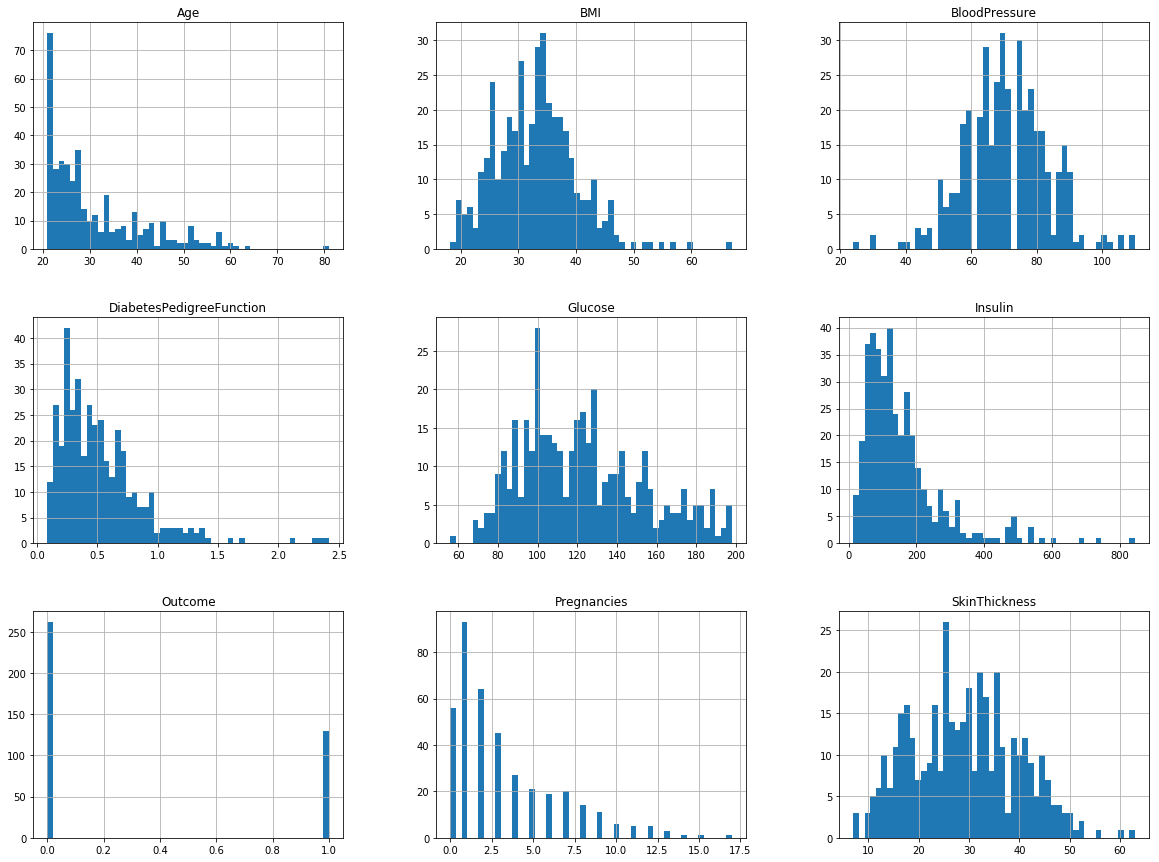

In [ ]:
# Histogram
pima_all.hist(bins=50, figsize=(20, 15))
plt.show()

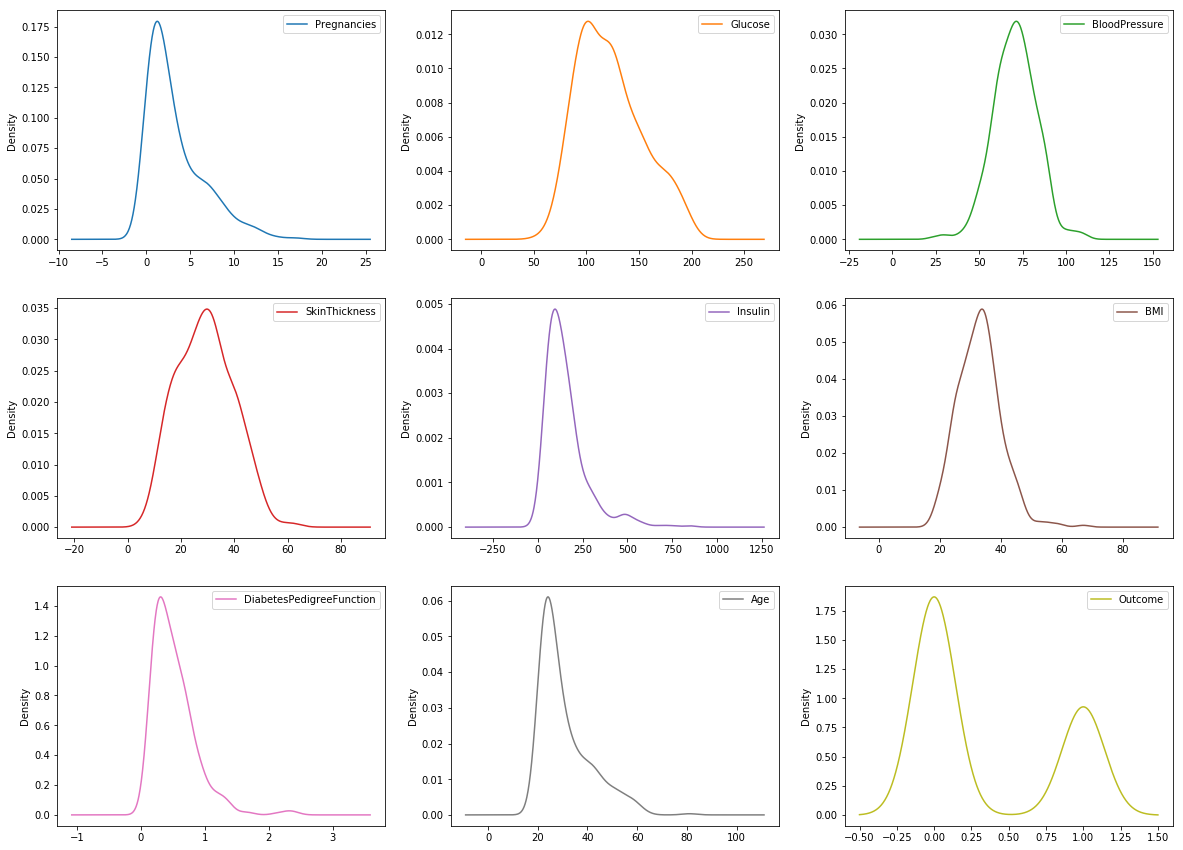

In [ ]:
# Density plots for all attributes to visualize the distribution of each attribute
pima_all.plot(kind='density', subplots=True, layout=(3,3), figsize=(20, 15), sharex=False)
plt.show()

Pregnancies                    AxesSubplot(0.125,0.657941;0.227941x0.222059)
Glucose                     AxesSubplot(0.398529,0.657941;0.227941x0.222059)
BloodPressure               AxesSubplot(0.672059,0.657941;0.227941x0.222059)
SkinThickness                  AxesSubplot(0.125,0.391471;0.227941x0.222059)
Insulin                     AxesSubplot(0.398529,0.391471;0.227941x0.222059)
BMI                         AxesSubplot(0.672059,0.391471;0.227941x0.222059)
DiabetesPedigreeFunction          AxesSubplot(0.125,0.125;0.227941x0.222059)
Age                            AxesSubplot(0.398529,0.125;0.227941x0.222059)
Outcome                        AxesSubplot(0.672059,0.125;0.227941x0.222059)
dtype: object

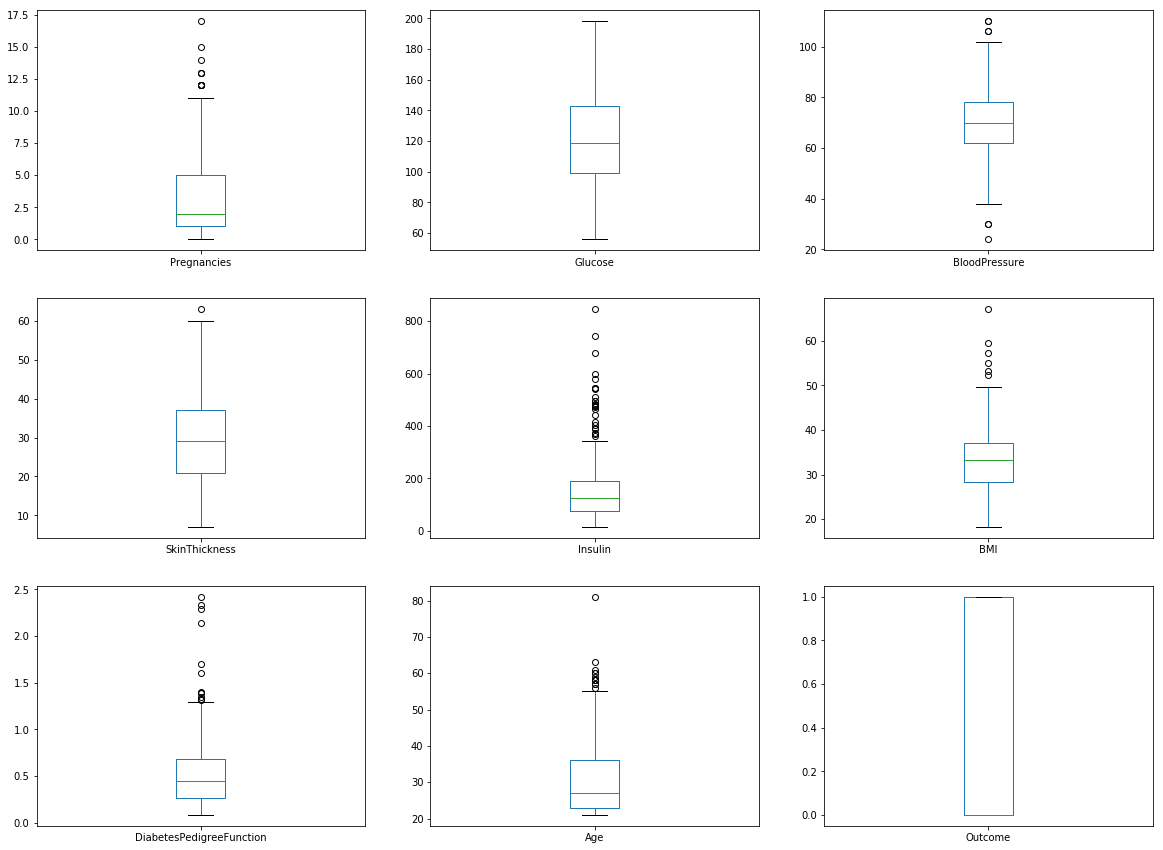

In [ ]:
#Box and Whisker plot to visualize the distribution of all atributes
pima_all.plot(kind= 'box' , subplots=True, layout=(3,3), sharex=False, sharey=False, figsize=(20,15))

In [ ]:
#Skew of attributes distributions
skew=pima_all.skew(axis = 1)

##### Bell shape curve: Blood Pressure
##### Right-Skewed: Age, Insulin, Pregnancies,  Diabetes Pedigree Function

##### Short IQR: insulin, Diabetes Pedigree Function, Blood Pressure and BMI
##### At least 75% of the women:
+ are 25 years old or older
+ have BMI nearly 30 kg/m2
+ have insulin level 100 or more
+ have 1 or more pregnancies
+ have glucose level of 100 mg/dL or more
+ have blood pressure of 60 mmHg or more

## Correlation

In [ ]:
# Correlation between the different characteristics. Closer to 1 better is the correlation.

corr_matrix_pearson = pima_all.corr(method='pearson')
corr_matrix_pearson

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.198291,0.213355,0.093209,0.078984,-0.025347,0.007562,0.679608,0.256566
Glucose,0.198291,1.000000,0.210027,0.198856,0.581223,0.209516,0.140180,0.343641,0.515703
BloodPressure,0.213355,0.210027,1.000000,0.232571,0.098512,0.304403,-0.015971,0.300039,0.192673
SkinThickness,0.093209,0.198856,0.232571,1.000000,0.182199,0.664355,0.160499,0.167761,0.255936
Insulin,0.078984,0.581223,0.098512,0.182199,1.000000,0.226397,0.135906,0.217082,0.301429
BMI,-0.025347,0.209516,0.304403,0.664355,0.226397,1.000000,0.158771,0.069814,0.270118
DiabetesPedigreeFunction,0.007562,0.140180,-0.015971,0.160499,0.135906,0.158771,1.000000,0.085029,0.209330
Age,0.679608,0.343641,0.300039,0.167761,0.217082,0.069814,0.085029,1.000000,0.350804
Outcome,0.256566,0.515703,0.192673,0.255936,0.301429,0.270118,0.209330,0.350804,1.000000


#### There are no strong correlation between the features. The 'strongest' ones are the following (as expected):
+ Age x pregnancies (0.68) - Older women tend to have higher number of pregnancies
+ Glucose x insulin (0.58)
+ Glucose x outcome (0.52) - Women that have higher level of glucose tend to have higher level of insulin and have DM
+ Skin fold thickness x BMI (0.66)  - Women with higher skin fold thickness value have higher BMI (and probably are overweight/obese)

##### Negative correlation:
+ BMI x Pregnancies (-0.025)
+ Blood Pressure x Diabetes Pedigree Function (-0.016)

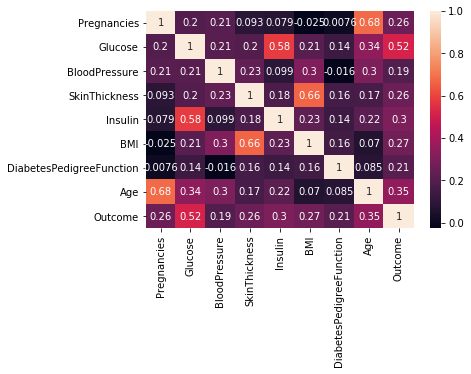

In [ ]:
sns.heatmap(corr_matrix_pearson, annot = True)

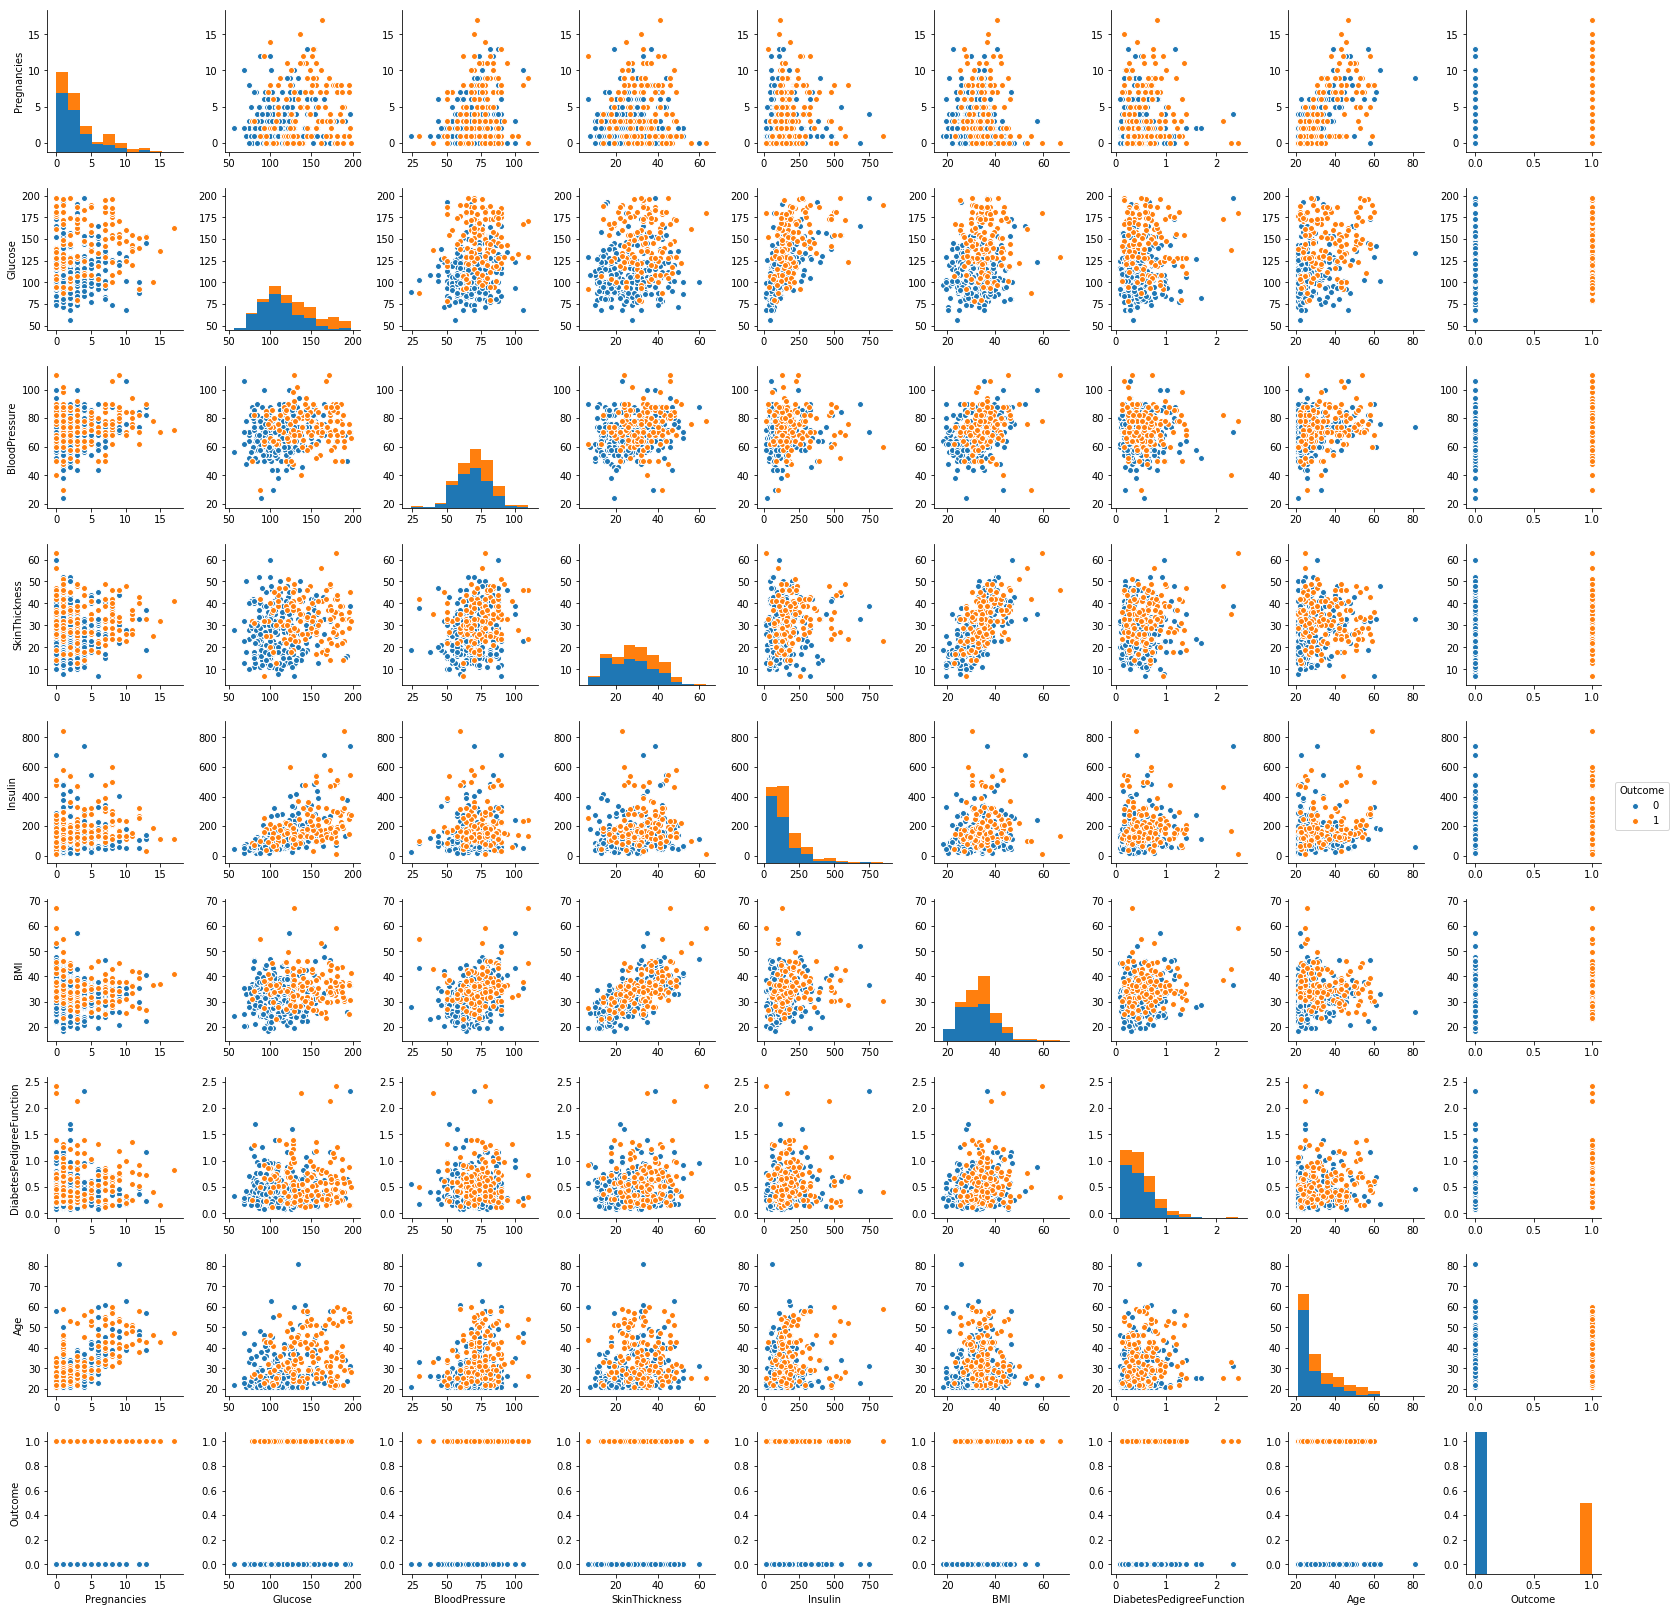

In [ ]:
# Pairplot

sns.pairplot(pima_all, hue='Outcome')

##### Diabetic women tend to show larger values of age, BMI, insulin, skin thickness, blood pressure, and pregnancies.
##### The feature that it is possible to see 2 distinct groups (diabetic and non diabetic) is glucose.

##### https://www.collaborat.com/pima-diabetes-data-discovery-predictive-model/

## Logic Regression

In [ ]:
#1st Iteration - 8 variables
var1=["Pregnancies", "Glucose","BloodPressure","SkinThickness","Insulin", "BMI","DiabetesPedigreeFunction", "Age"]
X=pima_all[var1]
y=pima_all.Outcome

In [ ]:
## Defining the model and assigning Y (Dependent) and X (Independent Variables)
logit_model=sm.Logit(y,X)

## Fitting the model and publishing the results
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.563677
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  392
Model:                          Logit   Df Residuals:                      384
Method:                           MLE   Df Model:                            7
Date:                Mon, 14 Dec 2020   Pseudo R-squ.:                  0.1128
Time:                        16:22:42   Log-Likelihood:                -220.96
converged:                       True   LL-Null:                       -249.05
                                        LLR p-value:                 8.717e-10
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Pregnancies                  0.1299      0.049      2.655      0.008       0.034

##### This model can explain 56% of the variation in dependent variable. SkinThickness, BMI, Diabetes Pedigree Function, Age, and Insulin are attributes to be eliminated in the next model. as variables that influence the outcome should have a p-value less than 0.05.

In [ ]:
#2nd Iteration - 3 variables
var2=["Pregnancies", "Glucose","BloodPressure"]
X=pima_all[var2]
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.574607
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  392
Model:                          Logit   Df Residuals:                      389
Method:                           MLE   Df Model:                            2
Date:                Mon, 14 Dec 2020   Pseudo R-squ.:                 0.09558
Time:                        16:22:42   Log-Likelihood:                -225.25
converged:                       True   LL-Null:                       -249.05
                                        LLR p-value:                 4.597e-11
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Pregnancies       0.1405      0.037      3.826      0.000       0.069       0.212
Glucose           0.

##### This model can explain 57% of the variation in dependent variable. All the variables show a p-value < 0.005.

In [ ]:
logreg = LogisticRegression()
var2=["Pregnancies", "Glucose","BloodPressure"]
X=pima_all[var2]
y=pima_all.Outcome
logreg.fit(X,y)

## Defining the y_pred variable for the predicting values.
y_pred=logreg.predict(X)

## Calculating the precision of the model
print(classification_report(y,y_pred))

             precision    recall  f1-score   support

          0       0.79      0.89      0.84       262
          1       0.71      0.53      0.61       130

avg / total       0.77      0.77      0.76       392



##### The model precision of model #2 (3 variables) is 77%.

In [ ]:
## Confusion matrix gives the number of cases that the model is able to accurately predict the outcomes, and the number of cases the model gives false positive and false negatives
confusion_matrix = confusion_matrix(y, y_pred)
print(confusion_matrix)

[[234  28]
 [ 61  69]]


##### The confusion matrix shows that 234 + 69 are correct predictions and 61 + 28 are incorrect predictions.

## Classifier

In [ ]:
# Predict the outcome - knn

inputs = pima_all[['Glucose', 'Insulin', 'SkinThickness', 'BMI', 'Age']]

In [ ]:
outputs = pima_all['Outcome']

In [ ]:
knn = nei.KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn.fit(inputs, outputs)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=5, p=2,
           weights='uniform')

In [ ]:
# Evaluate knn

(knn.predict(inputs) == outputs).sum()

322

##### From 392, 322 got correct outcome predicted.

In [ ]:
#Split the train set - 1/3 is to test

inputs_train, inputs_test, outputs_train, outputs_test = mod.train_test_split(inputs,outputs, test_size =0.33)

In [ ]:
knn = nei.KNeighborsClassifier(n_neighbors=5)
knn.fit(inputs_train, outputs_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=5, p=2,
           weights='uniform')

In [ ]:
(knn.predict(inputs_test) == outputs_test).sum()

99

In [ ]:
#Count how many women are Positive (1) and Negative (0) for diabetes in the test set

outputs_test.value_counts()

0    94
1    36
Name: Outcome, dtype: int64

## Check classification accuracy with knn = 5

In [ ]:
outputs_pred = knn.predict(inputs_test)
accuracy = metrics.accuracy_score(outputs_test, outputs_pred)
accuracy

0.7615384615384615

In [ ]:
# 10-fold cross-validation with knn = 5

scores = cross_val_score (knn, inputs, outputs, cv =10, scoring = 'accuracy')
scores

array([ 0.725     ,  0.8       ,  0.64102564,  0.61538462,  0.64102564,
        0.74358974,  0.66666667,  0.82051282,  0.76923077,  0.79487179])

In [ ]:
scores.mean()

0.72173076923076918

## Optimal value of k

In [ ]:
k_range = range(1,41)
k_scores = []

In [ ]:
for k in k_range:
    knn = nei.KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score (knn, inputs, outputs, cv = 10, scoring = 'accuracy')
    k_scores.append(scores.mean())

In [ ]:
k_scores

[0.72224358974358971,
 0.73967948717948717,
 0.72974358974358966,
 0.73698717948717951,
 0.72173076923076918,
 0.73961538461538456,
 0.75224358974358974,
 0.75237179487179484,
 0.74993589743589739,
 0.76256410256410256,
 0.77025641025641023,
 0.76256410256410256,
 0.76525641025641022,
 0.75743589743589745,
 0.74737179487179484,
 0.74724358974358973,
 0.75749999999999995,
 0.7549358974358974,
 0.75237179487179495,
 0.75756410256410256,
 0.755,
 0.74980769230769229,
 0.74724358974358973,
 0.7548717948717949,
 0.74724358974358984,
 0.74974358974358979,
 0.74717948717948723,
 0.75230769230769234,
 0.74717948717948723,
 0.75230769230769234,
 0.7548717948717949,
 0.75743589743589745,
 0.7548717948717949,
 0.75237179487179484,
 0.75743589743589745,
 0.75743589743589745,
 0.76762820512820507,
 0.76256410256410256,
 0.76000000000000001,
 0.7599358974358974]

Text(0,0.5,'Cross-validation accuracy')

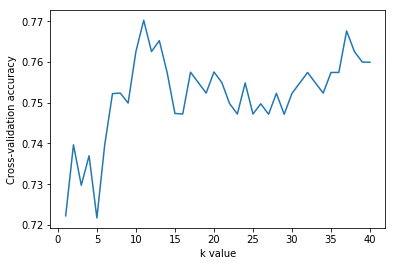

In [ ]:
#Visualise best k number

plt.plot(k_range, k_scores)
plt.xlabel ('k value')
plt.ylabel('Cross-validation accuracy')

In [ ]:
# Optimal value for k is 10

knn = nei.KNeighborsClassifier(n_neighbors=10)
knn.fit(inputs_train, outputs_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=10, p=2,
           weights='uniform')

In [ ]:
(knn.predict(inputs_test) == outputs_test).sum()

103

In [ ]:
outputs_pred = knn.predict(inputs_test)
accuracy = metrics.accuracy_score(outputs_test, outputs_pred)
accuracy #76.1%

0.79230769230769227

In [ ]:
# 10-fold cross-validation with knn = 3

scores = cross_val_score (knn, inputs, outputs, cv =10, scoring = 'accuracy')
scores #accuracy scores arrays (from 61.5% to 84.6%)

array([ 0.8       ,  0.8       ,  0.69230769,  0.61538462,  0.69230769,
        0.84615385,  0.71794872,  0.87179487,  0.79487179,  0.79487179])

In [ ]:
# Average accuracy score

scores.mean()

0.76256410256410256

## Cross Validation

### Recursive feature elimination with cross-validation

In [ ]:
kf = KFold(10, False, 1)

In [ ]:
skf = StratifiedKFold(n_splits=10, random_state=42)

In [ ]:
lg = LogisticRegression()

In [ ]:
rfecv = RFECV (estimator=lg,step=1, cv=skf, scoring='accuracy')

In [ ]:
rfecv.fit(inputs, outputs)

RFECV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=False),
   estimator=LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False),
   n_jobs=1, scoring='accuracy', step=1, verbose=0)

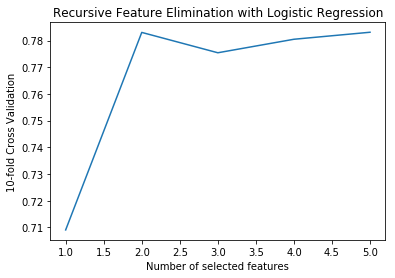

In [ ]:
plt.figure()
plt.title('Recursive Feature Elimination with Logistic Regression')
plt.xlabel('Number of selected features')
plt.ylabel('10-fold Cross Validation')
plt.plot(range(1, len(rfecv.grid_scores_) + 1), rfecv.grid_scores_)

plt.show()

#Optical number of features (=5) more suitable to predict the outcome

In [ ]:
feature_names = pima_all.columns[:10]
feature_names

Index(['Pregnancies', 'Glucose', 'Glucose Result', 'BloodPressure',
       'Percentile skin thickness', 'SkinThickness', 'Insulin', 'BMI',
       'Nutritional Status', 'DiabetesPedigreeFunction'],
      dtype='object')

In [ ]:
X = pima_all[feature_names]

In [ ]:
new_features = list(filter(lambda x: x[1],zip(feature_names, rfecv.support_)))
new_features

[('Pregnancies', True),
 ('Glucose', True),
 ('Glucose Result', True),
 ('BloodPressure', True),
 ('Percentile skin thickness', True)]

##### new_features are the features more suitable to predict the outcome (Diabetes)

### Knn and Accuracy score - new features (inputs) and optimal k value

In [ ]:
new_inputs = pima_all[['Pregnancies','Glucose', 'BloodPressure','SkinThickness']]

In [ ]:
knn = nei.KNeighborsClassifier(n_neighbors=10)

In [ ]:
knn.fit(new_inputs, outputs)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=10, p=2,
           weights='uniform')

In [ ]:
(knn.predict(new_inputs) == outputs).sum()

303

In [ ]:
new_inputs_train, new_inputs_test, outputs_train, outputs_test = mod.train_test_split(new_inputs,outputs, test_size =0.33)

In [ ]:
knn.fit(new_inputs_train, outputs_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=10, p=2,
           weights='uniform')

In [ ]:
(knn.predict(new_inputs_test) == outputs_test).sum()

93

In [ ]:
outputs_pred_new_inputs = knn.predict(new_inputs_test)
accuracy = metrics.accuracy_score(outputs_test, outputs_pred_new_inputs)
accuracy

0.7153846153846154

In [ ]:
scores = cross_val_score (knn, new_inputs, outputs, cv =10, scoring = 'accuracy')
scores.mean()

0.75262820512820505

### Logistic Regression

In [ ]:
lg = LogisticRegression()

In [ ]:
lg_accuracy = cross_val_score(lg,inputs,outputs,cv=10,scoring='accuracy')

In [ ]:
lg_accuracy.mean()

0.78314102564102561

##### Logistic Regression has a better average accuracy score than knn.

In [ ]:
lg.fit(inputs_train,outputs_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)

In [ ]:
outputs_pred=lg.predict(inputs_test)
accuracy_lg = metrics.accuracy_score(outputs_test, outputs_pred)
accuracy_lg

0.63846153846153841

### Naive Bayes

In [ ]:
mnb = MultinomialNB()
mnb.fit(inputs_train, outputs_train)
out_pred = mnb.predict(inputs_test)
accuracy_mnb = accuracy_score(outputs_test, out_pred)
accuracy_mnb

0.56923076923076921

### Confusion Matrix

In [ ]:
conf_mtx_nb = metrics.confusion_matrix(outputs_test, out_pred)
conf_mtx_nb

array([[65, 21],
       [35,  9]], dtype=int64)

In [ ]:
conf_mtx_new_features = metrics.confusion_matrix(outputs_test, outputs_pred_new_inputs)
conf_mtx_new_features

array([[68, 18],
       [19, 25]], dtype=int64)

##### In reality, 46 women in the sample have DM, and 84 women do not.
##### Naive Bayes: Out of those 130 cases, the classifier predicted "yes" 30 times, and "no" 100 times.
##### New Features and k = 10 : Out of those 130 cases, the classifier predicted "yes" 43 times, and "no" 87 times.

### Precision

In [ ]:
precision_nb = metrics.precision_score(outputs_test, out_pred)
precision_nb

0.29999999999999999

In [ ]:
precision_new_features = metrics.precision_score(outputs_test,outputs_pred_new_inputs)
precision_new_features

0.58139534883720934

##### 80% of the time individuals who were predict to be diabetic taking in account the "new features" and the k = 10 were in fact diabetic.

### Recall

In [ ]:
recall = metrics.recall_score(outputs_test, out_pred)
recall

0.20454545454545456

In [ ]:
recall_new_features = metrics.recall_score(outputs_test,outputs_pred_new_inputs)
recall_new_features

0.56818181818181823

##### The "new features" and k = 10 model can identify 43.5% of the time the individuals who are diabetic in the test set.

In [ ]:
class_rep = classification_report(outputs_test, out_pred)
class_rep

'             precision    recall  f1-score   support\n\n          0       0.65      0.76      0.70        86\n          1       0.30      0.20      0.24        44\n\navg / total       0.53      0.57      0.54       130\n'

In [ ]:
out_pred_prob = mnb.predict_proba(inputs_test)[:,1]
out_pred_prob

array([  2.40141417e-02,   6.69976661e-01,   9.58775991e-01,
         9.99962223e-01,   5.81884333e-02,   7.34357822e-01,
         1.75224500e-01,   1.14455437e-01,   1.41997077e-02,
         3.08905717e-01,   1.98384759e-01,   7.43078929e-03,
         7.53787240e-02,   8.36820433e-04,   2.09831073e-01,
         4.72987167e-02,   4.09500131e-02,   9.99989039e-01,
         2.30896808e-02,   6.34862602e-02,   8.75042920e-03,
         1.00000000e+00,   2.41755635e-01,   7.26611081e-03,
         9.99997822e-01,   8.01657971e-01,   5.61954379e-03,
         6.51243641e-02,   2.35319966e-02,   1.73694984e-02,
         8.39382201e-01,   2.19364135e-01,   9.98632128e-01,
         3.24840364e-03,   1.41031810e-01,   1.11497257e-01,
         4.82424809e-01,   5.22951545e-02,   3.12104770e-02,
         7.57952834e-01,   9.99968137e-01,   8.72617727e-01,
         8.77990898e-02,   1.15641453e-01,   1.13468910e-02,
         2.85704683e-02,   9.04170640e-02,   2.86853658e-02,
         2.37036491e-01,

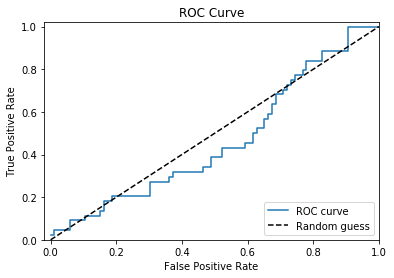

In [ ]:
fpr, tpr, thresholds = roc_curve(outputs_test, out_pred_prob)
# create plot
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
_ = plt.xlabel('False Positive Rate')
_ = plt.ylabel('True Positive Rate')
_ = plt.title('ROC Curve')
_ = plt.xlim([-0.02, 1])
_ = plt.ylim([0, 1.02])
_ = plt.legend(loc="lower right")

In [ ]:
ras = roc_auc_score(outputs_test, out_pred_prob)
ras

0.46405919661733619

##### The classifier is not very good at minimizing false negatives and true negatives

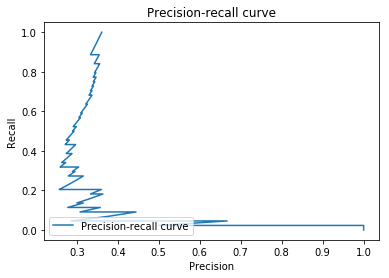

In [ ]:
precision, recall, thresholds = precision_recall_curve(outputs_test, out_pred_prob)
# create plot
plt.plot(precision, recall, label='Precision-recall curve')
_ = plt.xlabel('Precision')
_ = plt.ylabel('Recall')
_ = plt.title('Precision-recall curve')
_ = plt.legend(loc="lower left")

In [ ]:
aps = average_precision_score(outputs_test, out_pred_prob)
aps

0.34972403347787617

##### Low average precision score.

## CONCLUSION

##### Main conclusions will be written HERE!

## REFERENCE

1. TYNECKI P. Predict diabetes diagnosis for Pima Female Indians with Logistic Regression. 2018. Available on: https://www.kaggle.com/ptynecki/pima-indians-diabetes-prediction-with-lr-84.
2. SCHULZ LO, CHAUDHARI LS. High-Risk Populations: The Pimas of Arizona and Mexico
Curr Obes Rep. 2015 Mar 1; 4(1): 92–98. Available on: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4418458/
3. RUIZ-ALEJOS A, CARRILLO-LARCO RM, MIRANDA JJ, GILMAN RH, SMEETH L, BERNABE-Ortiz A. Skinfold thickness and the incidence of type 2 diabetes mellitus and hypertension: an analysis of the PERU MIGRANT study. Public Health Nutr. 2020;23(1):63-71. doi:10.1017/S1368980019001307
4. FRYAR CD, GU Q, OGDEN CL. Anthropometric reference data for children and adults: United States, 2007–2010. National Center for Health Statistics. Vital Health Stat 11(252). 2012.
5. VAN GAAL L., SCHEEN A. Weight Management in Type 2 Diabetes: Current and Emerging Approaches to Treatment, Diabetes Care 2015; 38(6): 1161 - 1172. Available on http://care.diabetesjournals.org/content/38/6/1161.
6. WILDING JPH. The importance of weight management in type 2 diabetes mellitus. Int J Clin Pract. 2014 Jun; 68(6): 682–691. Available on: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4238418/
7. KODESH I. Associations between Variables Regarding Diabetes for Pima Indian Women. Available on: https://rpubs.com/ikodesh/53189.
8. DIABETES UK. Oral Glucose Tolerance Test. 2019. Available on: https://www.diabetes.co.uk/oral-glucose-tolerance-test.html
9. NATIONAL INSTITUTE FOR HEALTH AND CARE EXCELLENCE - NICE. Guideline Hypertension in adults: diagnosis and management. 2019. Available on: https://www.nice.org.uk/guidance/ng136/documents/draft-guideline
10. BOER IH, BANGALORE S, BENETOS A, DAVIS AM, MICHOS ED, MUNTNER P, ROSSING P, ZOUNGAS S, BAKRIS G. Diabetes and Hypertension: A Position Statement by the American Diabetes Association. Diabetes Care 2017 Sep; 40(9): 1273-1284.
11. BLOOD PRESSURE UK. Low Blood Pressure. Available on:  http://www.bloodpressureuk.org/microsites/u40/Home/facts/Whatislow#:~:text=For%20instance%2C%20when%20the%20heart,between%2040%20to%20160%20mmHg.
12. CHANDRA-SELVI E, PAVITHRA N, SAIKUMAR P. Skin Fold Thickness in Diabetes Mellitus: A Simple Anthropometric Measurement May Bare the Different Aspects of Adipose Tissue. IOSR Journal of Dental and Medical Sciences (IOSR-JDMS) e-ISSN: 2279-0853, p-ISSN: 2279-0861.Volume 15, Issue 11 Ver. IX (November. 2016), PP 07-11.
13. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4287763/
14. https://www.sciencedirect.com/science/article/pii/S1646343913000734
15. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3417105/

# END